# Python Script for Master's Thesis

**Thesis title:** *Determinants and Elasticity of Czech Exports*  
**Author:** Petr Chaloupek ([petrchaloupek@gmail.com](mailto:petrchaloupek@gmail.com))  
**Faculty:** Faculty of Economics and Administration, Masaryk University  
**Year:** 2025  
**LinkedIn:** [https://www.linkedin.com/in/petrchaloupek/](https://www.linkedin.com/in/petrchaloupek/)  

---

This script contains the implementation of the model used in the thesis to estimate the determinants and elasticity of Czech exports.  

Required datasets are provided separately in `.xlsx` format (attached to the electronic submission and available in the GitHub repository).  

> **Note:** This script is intended as a supplementary material to the master's thesis and is not optimized for general use.  


## Import libraries, datafreme and data transformation

In [33]:
# Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import os
import statsmodels.api as sm
from statsmodels.tsa.filters.hp_filter import hpfilter

plt.style.use('seaborn-v0_8')


In [3]:
# Set the working directory
notebook_dir = os.getcwd() 
os.chdir(notebook_dir)

In [20]:
# Import dataset
data_path = os.path.join("Data", "df.xlsx")
df = pd.read_excel(data_path)

columns_to_round1 = ["GDP_Ger", "GDP_Sk", "GDP_Pol", "GDP_Fr", "GDP_Au", 
                     "GDP_It", "P_Cz", "P_Ger", "P_Sk", "P_Pol", "P_Fr", "P_Au", "P_It"]
df[columns_to_round1] = df[columns_to_round1].round(2)

columns_to_round2 = ["XR", "ULC", "Import"]
df[columns_to_round2] = df[columns_to_round2].round(3)

print(df.head())

        Date  Export   GDP_Ger    GDP_Sk   GDP_Pol    GDP_Fr   GDP_Au  \
0 2000-01-01  265447  595801.6  10570.20  60209.94  431559.5  62060.1   
1 2000-04-01  273804  600554.6  10620.96  60402.35  436384.2  62795.4   
2 2000-07-01  284184  600993.3  10623.35  62404.98  439740.2  63546.9   
3 2000-10-01  302375  598434.0  10521.37  64470.39  442413.8  64034.3   
4 2001-01-01  307443  611139.0  10711.84  66631.59  444726.2  63926.6   

     GDP_It      XR   P_Cz  P_Ger   P_Sk  P_Pol   P_Fr   P_Au   P_It     ULC  \
0  388892.7  35.771  89.52  91.91  73.38  84.82  89.90  90.60  87.90  71.824   
1  391455.2  36.289  89.82  91.93  74.90  86.30  90.07  90.80  88.17  72.016   
2  394994.8  35.459  91.04  92.47  75.90  88.55  90.70  91.26  88.90  72.935   
3  398822.1  34.911  91.97  93.13  76.85  89.85  91.21  91.96  89.48  74.602   
4  401960.3  34.798  93.17  93.38  78.66  90.53  91.20  92.42  89.77  74.895   

    Import  
0  103.400  
1  107.233  
2  108.667  
3  110.433  
4  107.533  


In [21]:
# Create new variable for foreing demand

weights = {
    "GDP_Ger": 0.518,
    "GDP_Sk": 0.128,
    "GDP_Pol": 0.111,
    "GDP_Fr": 0.086,
    "GDP_Au": 0.076,
    "GDP_It": 0.081
}

df["y"] = sum(df[col] * weight for col, weight in weights.items())

df["y"] = df["y"].round(2)

In [22]:
# Create new variables for price level
weights = {
    "P_Ger": 0.518,
    "P_Sk": 0.128,
    "P_Pol": 0.111,
    "P_Fr": 0.086,
    "P_Au": 0.076,
    "P_It": 0.081
}

df["P_for"] = sum(df[col] * weight for col, weight in weights.items())

df["P_for"] = df["P_for"].round(2)

In [28]:
# Create log variables
df["l_x"] = np.log(df["Export"])
df["l_y"] = np.log(df["y"])
df["l_e"] = np.log(df["XR"])
df["l_p_for"] = np.log(df["P_for"])
df["l_p_cz"] = np.log(df["P_Cz"])
df["l_ulc"] = np.log(df["ULC"])
df["l_m"] = np.log(df["Import"])

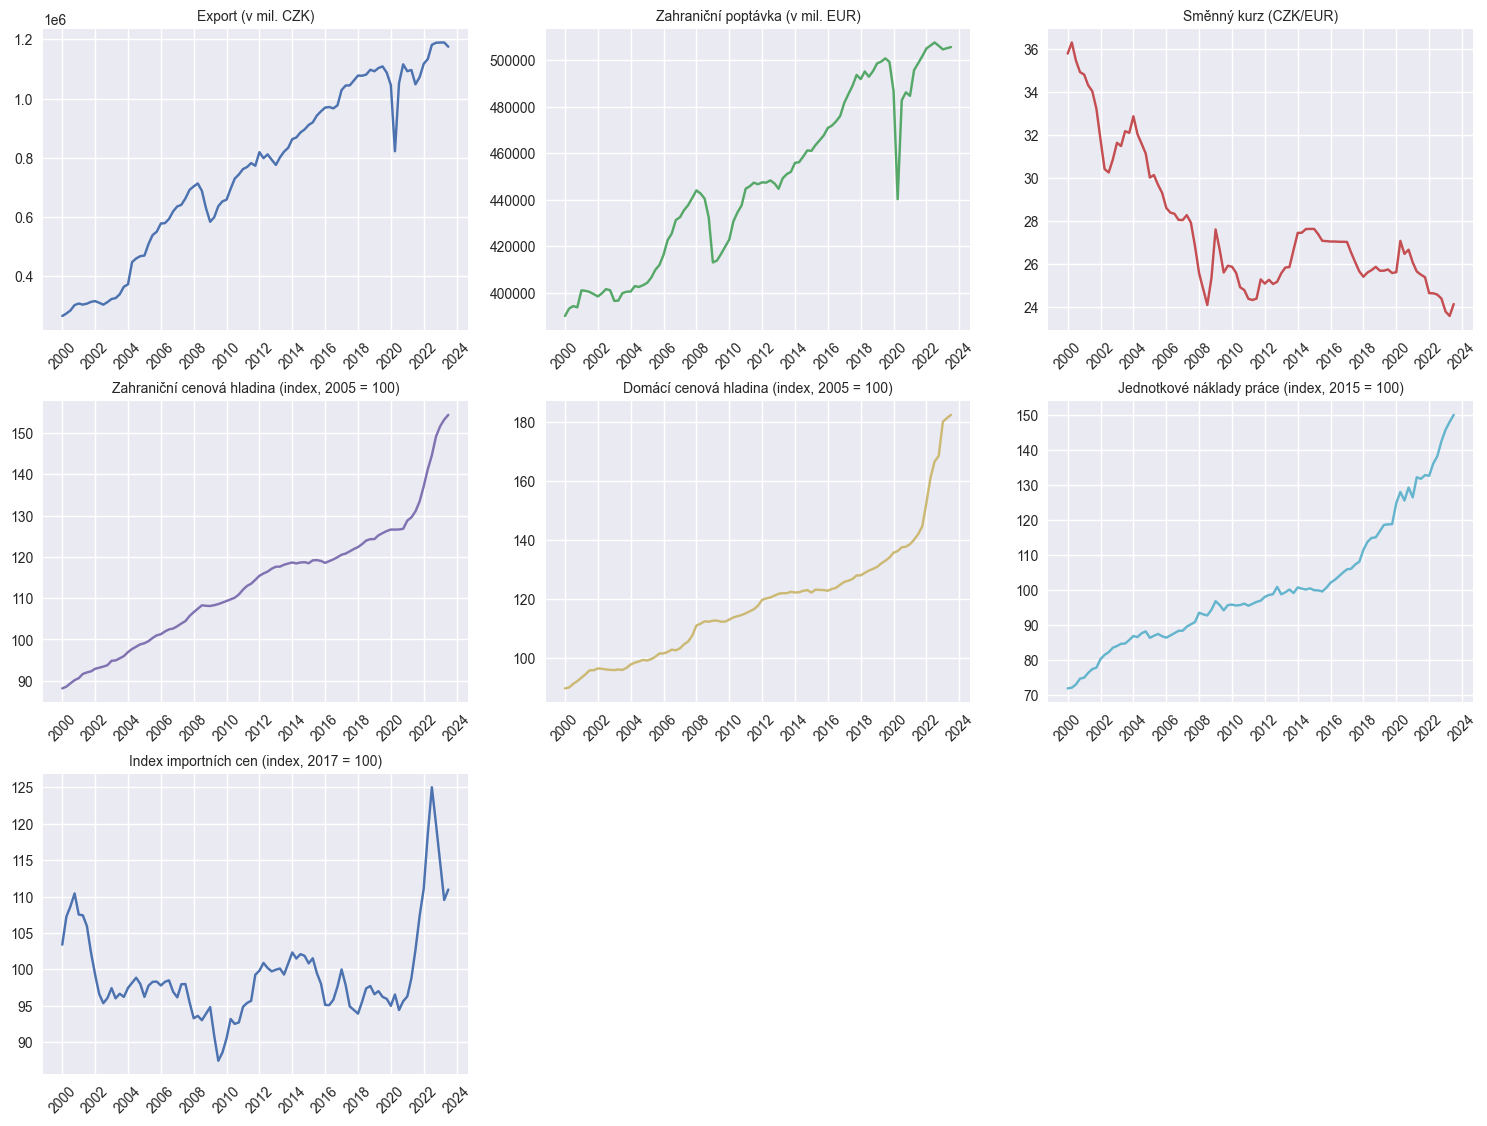

In [24]:
# Visualization of original variables
variables = ["Export", "y", "XR", "P_for", "P_Cz", "ULC", "Import"]
title_map = {
    "Export": "Export (v mil. CZK)",
    "y": "Zahraniční poptávka (v mil. EUR)",
    "XR": "Směnný kurz (CZK/EUR)",
    "P_for": "Zahraniční cenová hladina (index, 2005 = 100)",
    "P_Cz": "Domácí cenová hladina (index, 2005 = 100)",
    "ULC": "Jednotkové náklady práce (index, 2015 = 100)",
    "Import": "Index importních cen (index, 2017 = 100)"
}

df.index = pd.date_range(start='2000-01-01', end='2023-07-01', freq='QS')

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i, var in enumerate(variables):
    axes[i].plot(df.index, df[var], label=title_map[var], color=colors[i % len(colors)])
    axes[i].set_title(title_map[var], fontsize=10)
    axes[i].grid(True)

fig.delaxes(axes[-1])
fig.delaxes(axes[-2])

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.subplots_adjust(bottom=0.1)

# save_path = os.path.join("Obrázky", "cara.png")
# plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

## Estimation of gap variables

In [53]:
# Create first differences for specified variables (QoQ growth)
df['df_l_p_for'] = df['l_p_for'].diff().dropna()
df['df_l_p_cz'] = df['l_p_cz'].diff().dropna()
df['df_l_ulc'] = df['l_ulc'].diff(periods = 4).dropna()

In [54]:
# List of variables for gap estimation (use differenced for prices and ULC)
variables = ["l_x", "l_y", "l_e", "df_l_p_for", "df_l_p_cz", "df_l_ulc", "l_m"]

# Lambda for quarterly data (standard value for HP filter)
lamb = 1600

# Loop over all variables to estimate one-sided HP filter
for var in variables:
    # Get the series (handle differenced variables)
    y = df[var].dropna().values  # Convert to numpy array for indexing
    
    # Initialize arrays for trend and gap
    trend = np.full(len(df), np.nan)
    gap = np.full(len(df), np.nan)
    
    # One-sided HP filter: recursive estimation
    for t in range(len(y)):
        y_t = y[0:t+1]  # Data up to t
        if len(y_t) >= 2:  # HP needs at least 2 observations
            cycle_t, trend_t = hpfilter(y_t, lamb=lamb)
            trend[-len(y) + t] = trend_t[-1]  # Align with original index
        else:
            trend[-len(y) + t] = y_t[-1]  # For first observation, trend = y
    
    # Calculate gap
    gap[-len(y):] = y - trend[-len(y):]
    gap = gap * 100  # Convert to percentage
    
    # Save to DataFrame using .loc to avoid chained assignment warning
    df.loc[:, f"{var}_trnd"] = trend
    df.loc[:, f"{var}_gap"] = gap

/opt/anaconda3/envs/data_analysis/lib/python3.12/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)


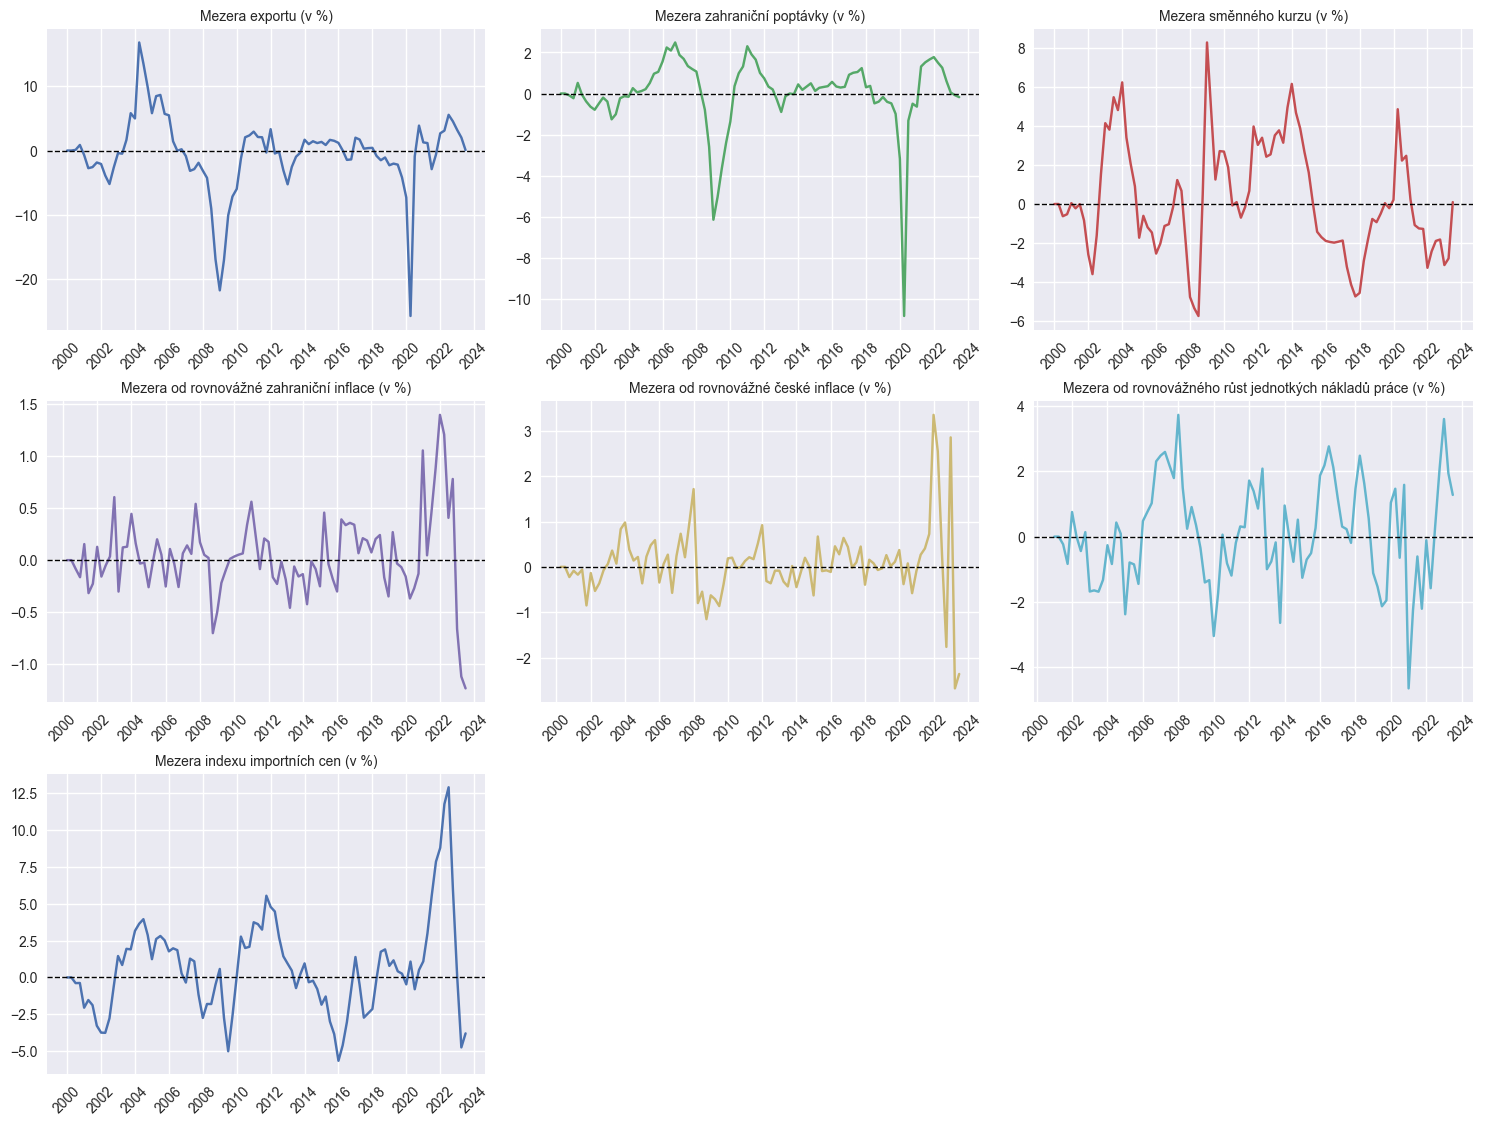

In [55]:
variables = ["l_x_gap", "l_y_gap", "l_e_gap", "df_l_p_for_gap", "df_l_p_cz_gap", "df_l_ulc_gap", "l_m_gap"]
title_map = {
    "l_x_gap": "Mezera exportu (v %)",
    "l_y_gap": "Mezera zahraniční poptávky (v %)",
    "l_e_gap": "Mezera směnného kurzu (v %)",
    "df_l_p_for_gap": "Mezera od rovnovážné zahraniční inflace (v %)",
    "df_l_p_cz_gap": "Mezera od rovnovážné české inflace (v %)",
    "df_l_ulc_gap": "Mezera od rovnovážného růst jednotkých nákladů práce (v %)",
    "l_m_gap": "Mezera indexu importních cen (v %)"
}

df.index = pd.date_range(start='2000-01-01', end='2023-07-01', freq='QS')

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i, var in enumerate(variables):
    axes[i].plot(df.index, df[var], label=title_map[var], color=colors[i % len(colors)])
    axes[i].set_title(title_map[var], fontsize=10)
    axes[i].axhline(0, color="black", linewidth=1, linestyle="--")
    axes[i].grid(True)

fig.delaxes(axes[-1])
fig.delaxes(axes[-2])

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.subplots_adjust(bottom=0.1)

# save_path = os.path.join("Obrázky", "cara_gap.png")
# plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

In [56]:
# Import necessary libraries
import pandas as pd
from statsmodels.tsa.stattools import adfuller

# List of gap variables
variables = ["l_x_gap", "l_y_gap", "l_e_gap", "df_l_p_for_gap", "df_l_p_cz_gap", "df_l_ulc_gap", "l_m_gap"]

# Initialize lists to store results
results = []

# Perform ADF test for each gap variable
for var in variables:
    result = adfuller(df[var].dropna())
    results.append({
        "Variable": [var],
        "Test Statistic": result[0],
        "p-value": result[1],
    })

# Create DataFrame from results
adf_table = pd.DataFrame(results)

# Save table to Excel
#save_path = os.path.join('Results', 'adf_test_results.xlsx')
#adf_table.to_excel(save_path, index=False)

print("\nADF Test Results:")
print(adf_table.to_string(index=False))


ADF Test Results:
        Variable  Test Statistic      p-value
       [l_x_gap]       -3.616775 5.448306e-03
       [l_y_gap]       -4.278936 4.830379e-04
       [l_e_gap]       -4.058167 1.134760e-03
[df_l_p_for_gap]       -6.004067 1.631301e-07
 [df_l_p_cz_gap]       -5.946655 2.196087e-07
  [df_l_ulc_gap]       -4.605206 1.263456e-04
       [l_m_gap]       -4.223668 6.006826e-04


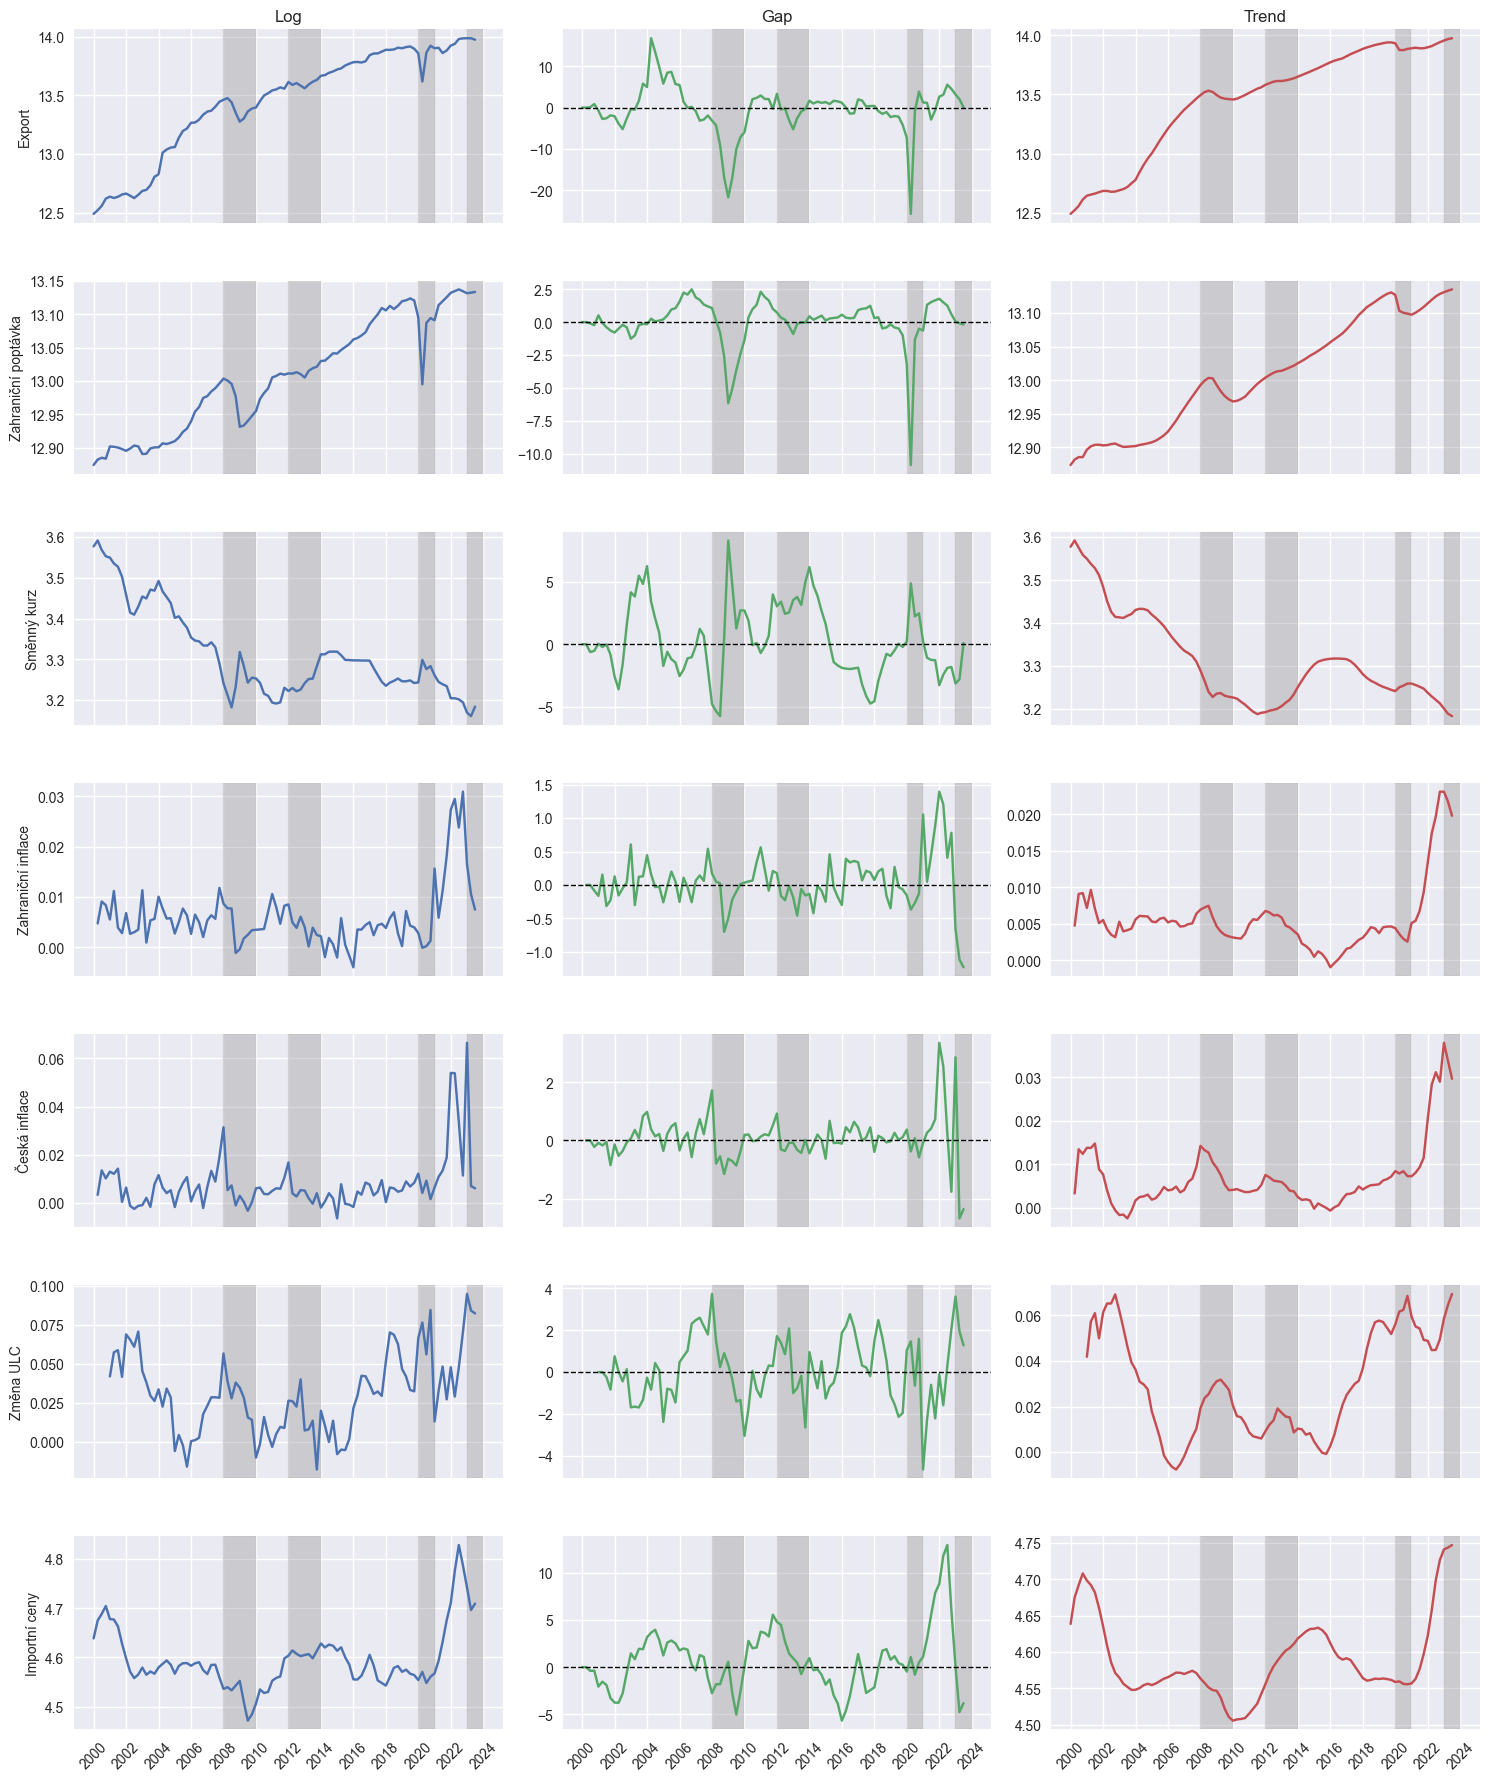

In [57]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Set index to quarterly data from Q1 2000 to Q3 2023
df.index = pd.date_range(start='2000-01-01', end='2023-07-01', freq='QS')

# List of variables
variables = ["l_x", "l_y", "l_e", "df_l_p_for", "df_l_p_cz", "df_l_ulc", "l_m"]

# Title map for each column
title_map = {
    "l_x": "Export",
    "l_y": "Zahraniční poptávka",
    "l_e": "Směnný kurz",
    "df_l_p_for": "Zahraniční inflace",
    "df_l_p_cz": "Česká inflace",
    "df_l_ulc": "Změna ULC",
    "l_m": "Importní ceny"
}

# Colors for original, gap, trend
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Recession periods
recessions = [
    (pd.to_datetime('2008-01-01'), pd.to_datetime('2009-12-31')),
    (pd.to_datetime('2012-01-01'), pd.to_datetime('2013-12-31')),
    (pd.to_datetime('2020-01-01'), pd.to_datetime('2020-12-31')),
    (pd.to_datetime('2023-01-01'), pd.to_datetime('2023-12-31'))
]

# Create subplots (7 rows, 3 columns)
fig, axes = plt.subplots(nrows=7, ncols=3, figsize=(15, 20), sharex=True)

# Column titles
col_titles = ["Log", "Gap", "Trend"]
for j, title in enumerate(col_titles):
    axes[0, j].set_title(title, fontsize=12)

# Plot for each variable
for i, var in enumerate(variables):
    # Original (log)
    axes[i, 0].plot(df.index, df[var], color=colors[0])
    axes[i, 0].set_ylabel(title_map[var], fontsize=10)
    axes[i, 0].grid(True)

    # Gap
    axes[i, 1].plot(df.index, df[f"{var}_gap"], color=colors[1])
    axes[i, 1].axhline(0, color="black", linewidth=1, linestyle="--")
    axes[i, 1].grid(True)

    # Trend
    axes[i, 2].plot(df.index, df[f"{var}_trnd"], color=colors[2])
    axes[i, 2].grid(True)

    # Highlight recessions in all columns
    for ax in axes[i]:
        for start, end in recessions:
            ax.axvspan(start, end, color='gray', alpha=0.3)

# Set x-axis formatting
for ax in axes.flatten():
    ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=45)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(bottom=0.1, top=0.95, hspace=0.3)

# Save plot (uncomment and adjust path if needed)
# save_path = os.path.join("Obrázky", "all_series.png")
# plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

In [58]:
gap_variables = ["l_x_gap", "l_y_gap", "l_e_gap", "df_l_p_for_gap", "df_l_p_cz_gap", "df_l_ulc_gap", "l_m_gap"]

# Calculate mean and variance for each gap variable
stats = {}
for var in gap_variables:
    stats[var] = {
        "Střední hodnota": df[var].mean(),
        "Rozptyl": df[var].var()
    }

# Create DataFrame from results
stats_df = pd.DataFrame(stats).T

# Display in console
print("Popisné statistiky gapů:")
print(stats_df.to_string())

# Save to text file
#save_path = "Results/gap_statistics.txt"
#stats_df.to_string(buf=save_path, index=True)
#print(f"\nStatistics saved to {save_path}")

Popisné statistiky gapů:
                Střední hodnota    Rozptyl
l_x_gap               -0.496622  34.736718
l_y_gap               -0.003685   3.157881
l_e_gap                0.221687   8.138263
df_l_p_for_gap         0.034032   0.155481
df_l_p_cz_gap          0.055639   0.648738
df_l_ulc_gap           0.099440   2.403797
l_m_gap                0.633926  10.547371


### Paskvyly

In [25]:
from hamilton_filter import hamilton_gap_trend

variables = ["l_x", "l_y", "l_e", "l_p_for", "l_p_cz", "l_ulc", "l_m"]

# Pro kvartální data Hamilton (2018) doporučuje h=8, p=4:
df = hamilton_gap_trend(df, variables, h=8, p=4)


KeyError: "Column 'l_x' not found in DataFrame."

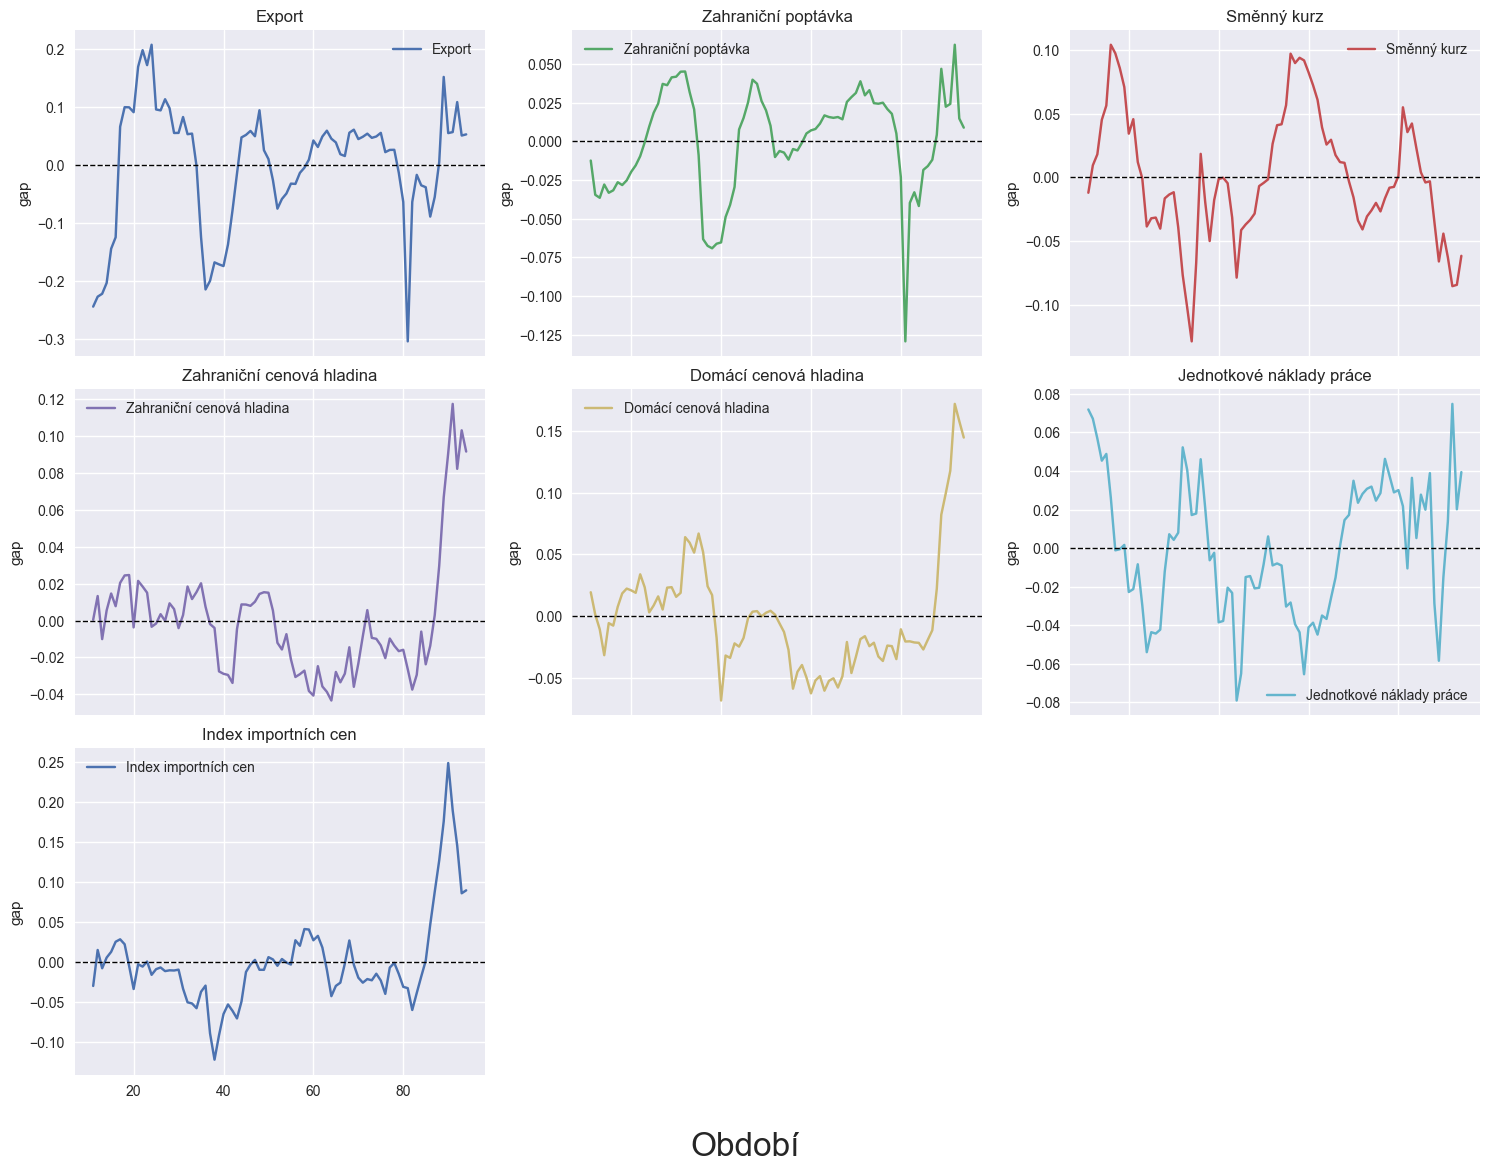

In [ ]:
# Vizualizace gapů (Hamilton filter)


variables = ["l_x", "l_y", "l_e", "l_p_for", "l_p_cz", "l_ulc", "l_m"]
title_map = {
    "l_x": "Export",
    "l_y": "Zahraniční poptávka",
    "l_e": "Směnný kurz",
    "l_p_for": "Zahraniční cenová hladina",
    "l_p_cz": "Domácí cenová hladina",
    "l_ulc": "Jednotkové náklady práce",
    "l_m": "Index importních cen"
}

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12), sharex=True)
axes = axes.flatten()

for i, var in enumerate(variables):
    gap_col = f"{var}_gap"
    axes[i].plot(df.index, df[gap_col], label=title_map[var], color=colors[i % len(colors)])
    axes[i].axhline(0, color="black", linewidth=1, linestyle="--")  # referenční osa
    axes[i].set_title(title_map[var], fontsize=12)
    axes[i].set_ylabel("gap")
    axes[i].grid(True)
    axes[i].legend()

# Zbylé prázdné osy odstraníme
fig.delaxes(axes[-1])
fig.delaxes(axes[-2])

fig.text(0.5, 0.04, "Období", ha="center", va="center", fontsize=24)
plt.tight_layout()
plt.subplots_adjust(bottom=0.1)

# Volitelně ukládání
# save_path = os.path.join("Obrázky", "gapy.png")
# plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()


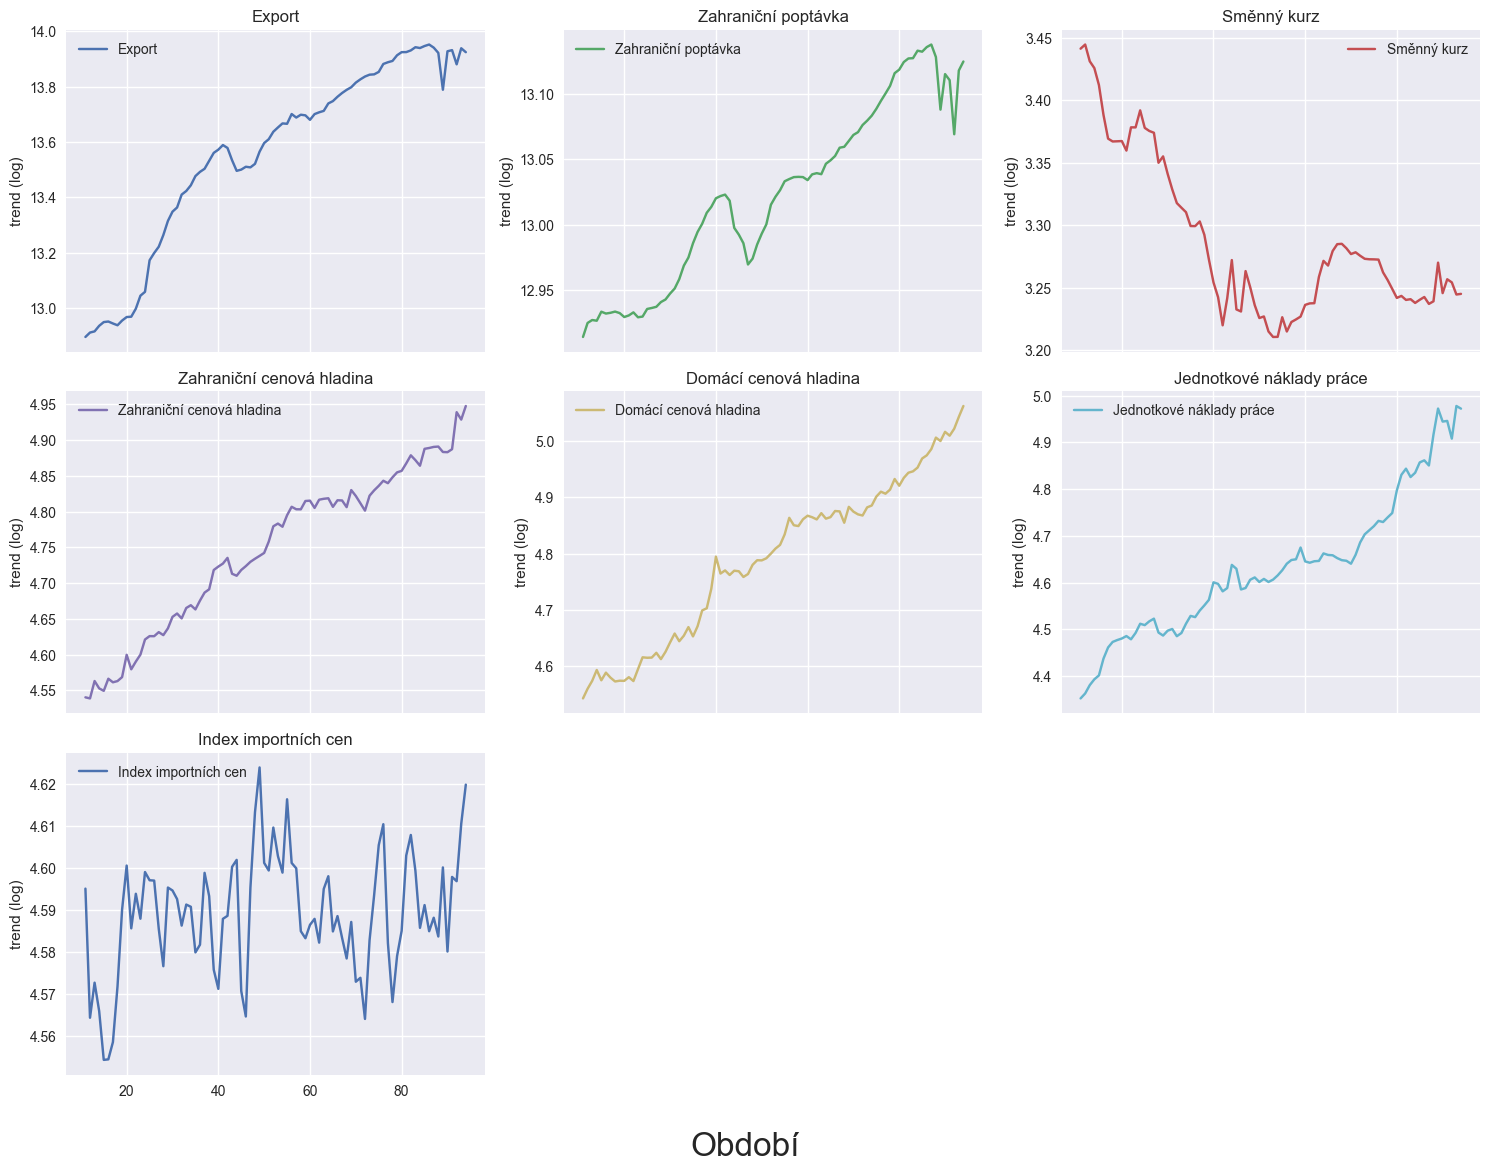

In [ ]:
# Vizualizace trendů (Hamilton filter)
import matplotlib.pyplot as plt
import os

variables = ["l_x", "l_y", "l_e", "l_p_for", "l_p_cz", "l_ulc", "l_m"]
title_map = {
    "l_x": "Export",
    "l_y": "Zahraniční poptávka",
    "l_e": "Směnný kurz",
    "l_p_for": "Zahraniční cenová hladina",
    "l_p_cz": "Domácí cenová hladina",
    "l_ulc": "Jednotkové náklady práce",
    "l_m": "Index importních cen"
}

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12), sharex=True)
axes = axes.flatten()

for i, var in enumerate(variables):
    trnd_col = f"{var}_trnd"
    axes[i].plot(df.index, df[trnd_col], label=title_map[var], color=colors[i % len(colors)])
    axes[i].set_title(title_map[var], fontsize=12)
    axes[i].set_ylabel("trend (log)")
    axes[i].grid(True)
    axes[i].legend()

# Zbylé prázdné osy odstraníme
fig.delaxes(axes[-1])
fig.delaxes(axes[-2])

fig.text(0.5, 0.04, "Období", ha="center", va="center", fontsize=24)
plt.tight_layout()
plt.subplots_adjust(bottom=0.1)

# Volitelně ukládání
# save_path = os.path.join("Obrázky", "trendy.png")
# plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()


In [ ]:
# === 1) Výpočet HP gapů pro vybrané proměnné (quarterly, λ = 1600) ===
import numpy as np
import pandas as pd
from statsmodels.tsa.filters.hp_filter import hpfilter  # musí být nainstalováno statsmodels

variables = ["l_x", "l_y", "l_e", "l_p_for", "l_p_cz", "l_ulc", "l_m"]

# Pro HP filtr na kvartálních datech se běžně používá lambda = 1600
HP_LAMBDA = 1600

for var in variables:
    if var not in df.columns:
        raise KeyError(f"Chybí sloupec '{var}' v df.")
    s = df[var].astype(float)
    mask = s.notna()

    if mask.sum() < 5:
        # příliš málo bodů -> ulož prázdné NaNy (raději fail-safe než počítat nesmysly)
        df[f"{var}_gap_hp"]  = np.nan
        df[f"{var}_trnd_hp"] = np.nan
        continue

    # HP filtr aplikuj jen na nenulové hodnoty (bez NaN) a pak zarovnej zpět
    cycle, trend = hpfilter(s[mask], lamb=HP_LAMBDA)

    df[f"{var}_gap_hp"]  = np.nan
    df[f"{var}_trnd_hp"] = np.nan
    df.loc[mask, f"{var}_gap_hp"]  = cycle.values
    df.loc[mask, f"{var}_trnd_hp"] = trend.values

# Rychlá kontrola posledních pár řádků:
# df[[f"{v}_gap_hp" for v in variables]].tail()


/opt/anaconda3/envs/data_analysis/lib/python3.12/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)
/opt/anaconda3/envs/data_analysis/lib/python3.12/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)
/opt/anaconda3/envs/data_analysis/lib/python3.12/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)
/opt/anaconda3/envs/data_analysis/lib/python3.12/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)
/opt/anaconda3/envs/data_analysi

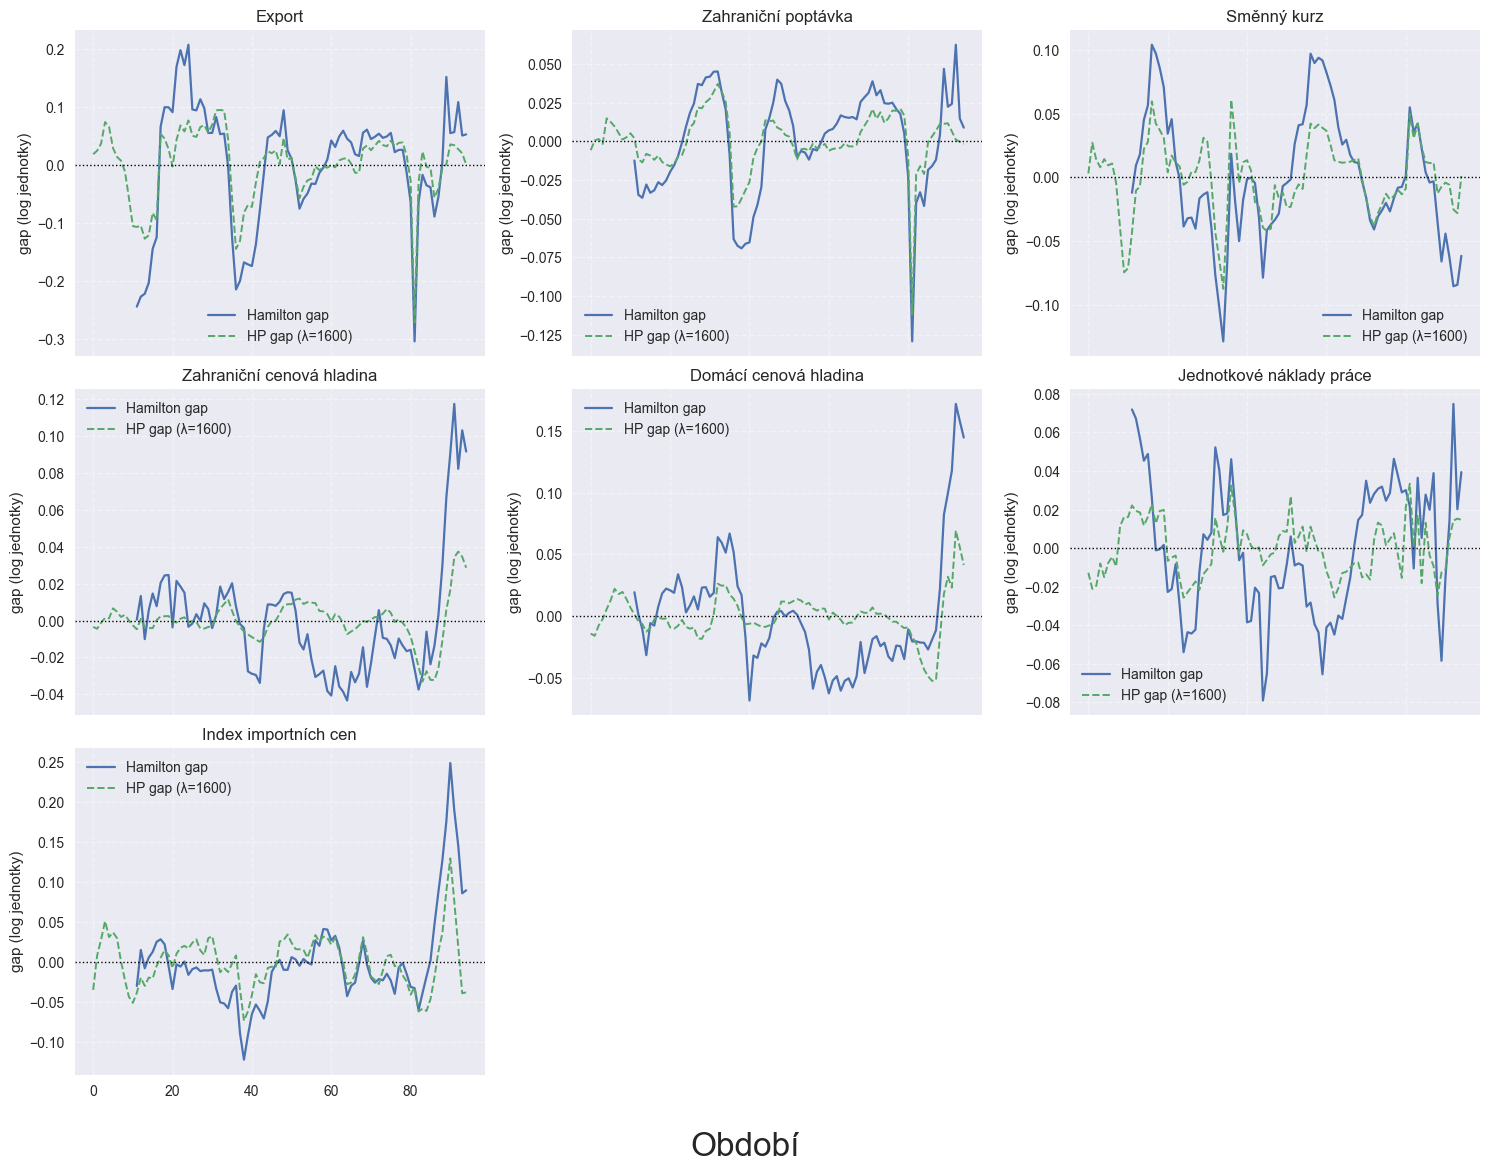

In [ ]:
# === 2) Vizualizace: Hamilton gap vs HP gap (3x3 mřížka) ===
import matplotlib.pyplot as plt

variables = ["l_x", "l_y", "l_e", "l_p_for", "l_p_cz", "l_ulc", "l_m"]
title_map = {
    "l_x": "Export",
    "l_y": "Zahraniční poptávka",
    "l_e": "Směnný kurz",
    "l_p_for": "Zahraniční cenová hladina",
    "l_p_cz": "Domácí cenová hladina",
    "l_ulc": "Jednotkové náklady práce",
    "l_m": "Index importních cen"
}

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
color_ham = colors[0]  # Hamilton gap
color_hp  = colors[1]  # HP gap

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12), sharex=True)
axes = axes.flatten()

for i, var in enumerate(variables):
    ham_col = f"{var}_gap"      # Hamilton (už spočítané)
    hp_col  = f"{var}_gap_hp"   # HP (dopočítané výše)

    if ham_col not in df.columns:
        raise KeyError(f"Chybí '{ham_col}'. Nejdřív spočítej Hamilton gapy.")
    if hp_col not in df.columns:
        raise KeyError(f"Chybí '{hp_col}'. Nejdřív spočítej HP gapy.")

    ax = axes[i]
    ax.plot(df.index, df[ham_col], label="Hamilton gap", linewidth=1.6, color=color_ham)
    ax.plot(df.index, df[hp_col],  label="HP gap (λ=1600)", linewidth=1.4, linestyle="--", color=color_hp)
    ax.axhline(0, linewidth=1.0, linestyle=":", color="black")

    ax.set_title(title_map[var], fontsize=12)
    ax.set_ylabel("gap (log jednotky)")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend()

# Zbylé prázdné osy (3x3 > 7 proměnných)
fig.delaxes(axes[-1])
fig.delaxes(axes[-2])

fig.text(0.5, 0.04, "Období", ha="center", va="center", fontsize=24)
plt.tight_layout()
plt.subplots_adjust(bottom=0.1)

# Volitelné uložení:
# import os
# os.makedirs("Obrázky", exist_ok=True)
# plt.savefig(os.path.join("Obrázky", "gapy_hamilton_vs_hp.png"), dpi=300, bbox_inches="tight")

plt.show()



In [ ]:
# === Diagnostický balíček pro gapy ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.signal import periodogram

variables = ["l_x", "l_y", "l_e", "l_p_for", "l_p_cz", "l_ulc", "l_m"]

def adf_pvalue(x, maxlag=8):
    x = pd.Series(x).dropna()
    if len(x) < 10:
        return np.nan
    try:
        return adfuller(x, maxlag=min(maxlag, len(x)//3), autolag='AIC')[1]
    except Exception:
        return np.nan

def kpss_pvalue(x, regression='c', nlags='auto'):
    # KPSS není vždy v základním importu ve starších verzích statsmodels
    try:
        from statsmodels.tsa.stattools import kpss
    except Exception:
        return np.nan
    x = pd.Series(x).dropna()
    if len(x) < 10:
        return np.nan
    try:
        return kpss(x, regression=regression, nlags=nlags)[1]
    except Exception:
        return np.nan

def ljung_box_pvalue(x, lags=12):
    x = pd.Series(x).dropna()
    if len(x) < lags + 5:
        return np.nan
    try:
        return acorr_ljungbox(x, lags=[lags], return_df=True)['lb_pvalue'].iloc[0]
    except Exception:
        return np.nan

def power_in_band(x, fs_per_year=4, low_period_q=6, high_period_q=32):
    """
    Podíl výkonu ve frekvenčním pásmu odpovídajícímu periodám 6–32 čtvrtletí.
    """
    x = pd.Series(x).dropna().values
    if len(x) < 20:
        return np.nan
    # periodogram (jednostranný)
    f, Pxx = periodogram(x, scaling='spectrum')
    # převod frekvence na periodu v čtvrtletích: period_q = fs / f
    # Vyřaď nulovou frekvenci (trend)
    mask = (f > 0)
    f, Pxx = f[mask], Pxx[mask]
    period_q = fs_per_year / f
    band = (period_q >= low_period_q) & (period_q <= high_period_q)
    if Pxx.sum() == 0:
        return np.nan
    return float(Pxx[band].sum() / Pxx.sum())

def reconstruction_error(level, gap, trend):
    # RMS error level vs (gap+trend)
    s = pd.concat([level, gap, trend], axis=1).dropna()
    if s.empty:
        return np.nan
    err = (s.iloc[:,0] - (s.iloc[:,1] + s.iloc[:,2])).pow(2).mean() ** 0.5
    return float(err)

def sign_concordance(a, b):
    s = pd.concat([a, b], axis=1).dropna()
    if s.empty:
        return np.nan
    same_sign = np.sign(s.iloc[:,0]) == np.sign(s.iloc[:,1])
    return float(same_sign.mean())

rows = []
for var in variables:
    level = df[var].astype(float)
    gh = df.get(f"{var}_gap")
    th = df.get(f"{var}_trnd")
    ghp = df.get(f"{var}_gap_hp")
    thp = df.get(f"{var}_trnd_hp")

    # základní korelace H vs HP
    corr_h_hp = pd.concat([gh, ghp], axis=1).corr().iloc[0,1] if gh is not None and ghp is not None else np.nan
    concord = sign_concordance(gh, ghp)

    # stacionarita a serialita (na Hamilton gapu)
    adf_p = adf_pvalue(gh)
    kpss_p = kpss_pvalue(gh, regression='c')  # stationarity around constant
    lb_p = ljung_box_pvalue(gh, lags=12)

    # frekvenční pásmo (6–32Q)
    band_share = power_in_band(gh, fs_per_year=4, low_period_q=6, high_period_q=32)

    # rekonstrukční chyba (měla by být malá)
    rec_err_H = reconstruction_error(level, gh, th) if gh is not None and th is not None else np.nan
    rec_err_HP = reconstruction_error(level, ghp, thp) if ghp is not None and thp is not None else np.nan

    rows.append({
        "var": var,
        "corr(H,HP)": corr_h_hp,
        "sign_concord(H,HP)": concord,
        "ADF p (H gap)": adf_p,          # chceme malé (např. < 0.05)
        "KPSS p (H gap)": kpss_p,        # chceme spíše velké (např. > 0.10)
        "LB p(12) (H gap)": lb_p,        # velké => rezidua se „nehroutí“ do silné autocorr.
        "Power 6–32Q share (H gap)": band_share,  # vyšší je lépe (cykličnost)
        "RMS recon err H": rec_err_H,
        "RMS recon err HP": rec_err_HP,
        "N obs": int(pd.Series(gh).dropna().shape[0]) if gh is not None else 0
    })

diag = pd.DataFrame(rows).set_index("var")
diag


/var/folders/1b/x_b0byr51fz1qtfy12vcgbkm0000gn/T/ipykernel_84270/2302328751.py:32: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  return kpss(x, regression=regression, nlags=nlags)[1]
/var/folders/1b/x_b0byr51fz1qtfy12vcgbkm0000gn/T/ipykernel_84270/2302328751.py:32: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  return kpss(x, regression=regression, nlags=nlags)[1]
/var/folders/1b/x_b0byr51fz1qtfy12vcgbkm0000gn/T/ipykernel_84270/2302328751.py:32: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  return kpss(x, regression=regression, nlags=nlags)[1]
/var/folders/1b/x_b0byr51fz1qtfy12vcgbkm0000gn/T/ipykernel_84270/2302328751.py:32:

,"corr(H,HP)","sign_concord(H,HP)",ADF p (H gap),KPSS p (H gap),LB p(12) (H gap),Power 6–32Q share (H gap),RMS recon err H,RMS recon err HP,N obs
var,,,,,,,,,
l_x,0.891550,0.857143,0.048840,0.100000,1.092361e-33,0.152912,0.0,0.0,84
l_y,0.869590,0.797619,0.007275,0.100000,6.204180e-44,0.137015,0.0,0.0,84
l_e,0.790512,0.773810,0.109991,0.100000,6.779995e-33,0.092371,0.0,0.0,84
l_p_for,0.617831,0.654762,0.603477,0.100000,8.424936e-28,0.083112,0.0,0.0,84
l_p_cz,0.612519,0.583333,0.270183,0.100000,1.935449e-28,0.056639,0.0,0.0,84
l_ulc,0.566243,0.654762,0.138331,0.100000,4.587377e-22,0.178793,0.0,0.0,84
l_m,0.686447,0.654762,0.161486,0.068537,5.997235e-32,0.068410,0.0,0.0,84


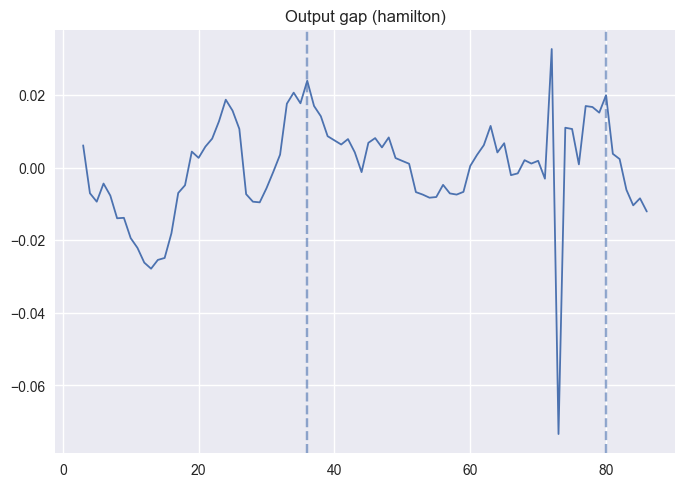

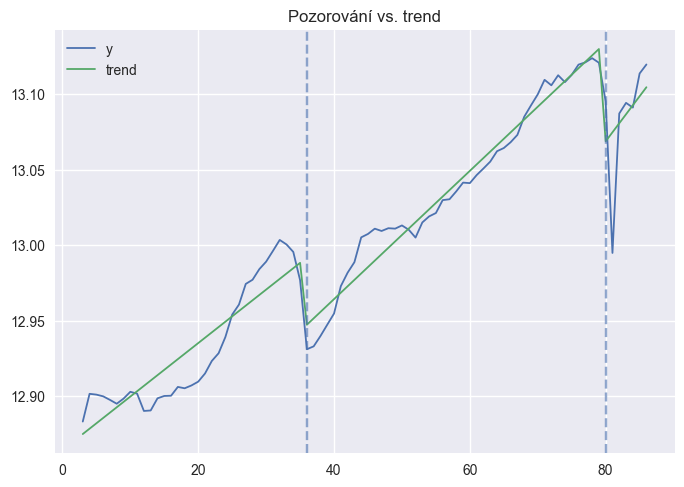

Zlomy (indexy): (36, 80)
           y      trend       gap  break1  break2
3  12.883371  12.875113  0.006183       0       0
4  12.901719  12.878653 -0.007017       0       0
5  12.901190  12.882192 -0.009337       0       0
6  12.900058  12.885732 -0.004344       0       0
7  12.897703  12.889271 -0.007662       0       0


In [ ]:
# -*- coding: utf-8 -*-
# Output gap: piecewise lineární trend (0/1/2 zlomy vybrané BIC) + filtr (Hamilton nebo CF)
# Funguje na df["l_y"] i bez časového indexu.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# CF filtr – kompatibilní import
try:
    from statsmodels.tsa.filters.cf_filter import cffilter
except Exception:
    from statsmodels.tsa.filters import cffilter  # fallback pro starší statsmodels

# ------------- Pomocné funkce (OLS, BIC, design) -------------

def _ols_fit(X, y):
    X = np.asarray(X, float)
    y = np.asarray(y, float).reshape(-1, 1)
    XtX = X.T @ X
    Xty = X.T @ y
    beta = np.linalg.solve(XtX, Xty)               # stabilnější než lstsq pro malé X
    fitted = (X @ beta).ravel()
    resid = (y.ravel() - fitted)
    sse = float(resid @ resid)
    return beta.ravel(), fitted, resid, sse

def _bic(n, sse, k):
    sigma2 = sse / max(n, 1)
    return n * np.log(sigma2) + k * np.log(max(n, 2))

def _design_no_break(t):
    return np.column_stack([np.ones(len(t)), t])

def _design_one_break(t, k1):
    D1 = (t >= k1).astype(float)
    return np.column_stack([np.ones_like(t), t, D1, t*D1])

def _design_two_breaks(t, k1, k2):
    k1, k2 = int(k1), int(k2)
    if k2 <= k1:
        k1, k2 = k2, k1
    D1 = (t >= k1).astype(float)
    D2 = (t >= k2).astype(float)
    return np.column_stack([np.ones_like(t), t, D1, t*D1, D2, t*D2])

def _search_breaks(y, max_breaks=2, min_seg_len=8):
    """Najdi 0/1/2 zlomy podle BIC s minimální délkou segmentu."""
    y = np.asarray(y, float)
    n = len(y)
    t = np.arange(n, dtype=float)

    # 0 zlomů
    X0 = _design_no_break(t)
    _, f0, r0, sse0 = _ols_fit(X0, y)
    best = (_bic(n, sse0, X0.shape[1]), f0, r0, None)

    # 1 zlom
    if n >= 2 * min_seg_len + 1:
        for k1 in range(min_seg_len, n - min_seg_len):
            X1 = _design_one_break(t, k1)
            _, f1, r1, sse1 = _ols_fit(X1, y)
            bic1 = _bic(n, sse1, X1.shape[1])
            if bic1 < best[0]:
                best = (bic1, f1, r1, (k1,))

    # 2 zlomy
    if n >= 3 * min_seg_len + 2:
        for k1 in range(min_seg_len, n - 2 * min_seg_len):
            for k2 in range(k1 + min_seg_len, n - min_seg_len):
                X2 = _design_two_breaks(t, k1, k2)
                _, f2, r2, sse2 = _ols_fit(X2, y)
                bic2 = _bic(n, sse2, X2.shape[1])
                if bic2 < best[0]:
                    best = (bic2, f2, r2, (k1, k2))

    breaks = None if best[3] is None else tuple(sorted(best[3]))
    return best[1], best[2], breaks

def _trend_with_known_breaks(y, break_idxs):
    y = np.asarray(y, float)
    n = len(y)
    t = np.arange(n, dtype=float)
    if not break_idxs:
        X = _design_no_break(t)
    elif len(break_idxs) == 1:
        X = _design_one_break(t, int(break_idxs[0]))
    elif len(break_idxs) == 2:
        X = _design_two_breaks(t, int(break_idxs[0]), int(break_idxs[1]))
    else:
        raise ValueError("Podporovány jsou max. dva zlomy.")
    _, fitted, resid, _ = _ols_fit(X, y)
    return fitted, resid

# -------------------- Hamiltonův filtr (opravené zarovnání) --------------------

def hamilton_cycle(resid, h=8, p=4):
    """
    Hamilton (2018): u_t = y_{t+h} - (alpha + beta'*[y_t, y_{t-1}, ..., y_{t-p+1}])
    Definováno pro t = p-1 ... n-h-1. Délka výstupu: T = n - h - (p - 1).
    """
    s = pd.Series(resid) if not isinstance(resid, pd.Series) else resid.copy()
    y = s.values.astype(float)
    n = len(y)
    if n <= h + p:
        raise ValueError(f"Řada je krátká pro h={h}, p={p}. Potřeba n > h + p.")

    T = n - h - (p - 1)                    # společná délka
    t0 = p - 1                             # první t
    # Y: y_{t+h} pro t = t0 ... t0+T-1  => indexy: (t0+h) ... (t0+h+T-1)
    Y = y[t0 + h : t0 + h + T]             # délka T

    # X: [1, y_t, y_{t-1}, ..., y_{t-p+1}] pro stejné t
    X_cols = [np.ones(T)]
    for j in range(p):
        # y_{t - j}  => indexy: (t0 - j) ... (t0 - j + T - 1)
        X_cols.append(y[t0 - j : t0 - j + T])
    X = np.column_stack(X_cols)            # tvar (T, p+1)

    # OLS pomocná regrese
    beta = np.linalg.lstsq(X, Y, rcond=None)[0]
    Y_hat = X @ beta
    u = Y - Y_hat

    # Zarovnání na původní index: u_t patří k t = t0 ... t0+T-1
    out_idx = s.index[t0 : t0 + T]
    return pd.Series(u, index=out_idx, name="gap")

# -------------------- Hlavní funkce --------------------

def estimate_gap(df, col="l_y",
                 known_break_idxs=None,   # např. (idx_2008, idx_2020) nebo None
                 min_seg_len=8,
                 method="hamilton",       # "hamilton" nebo "cf"
                 h=8, p=4,                # Hamilton parametry
                 low_period=6, high_period=40,  # CF parametry
                 plot=True):

    if col not in df.columns:
        raise ValueError(f"Sloupec '{col}' v df neexistuje.")
    y = pd.Series(df[col].astype(float).values, index=pd.RangeIndex(len(df)), name=col).dropna()
    y_np = y.values

    # 1) detrend (0/1/2 zlomy)
    if known_break_idxs is None:
        trend_hat, resid, break_idxs = _search_breaks(y_np, max_breaks=2, min_seg_len=min_seg_len)
    else:
        trend_hat, resid = _trend_with_known_breaks(y_np, known_break_idxs)
        break_idxs = tuple(sorted(known_break_idxs)) if known_break_idxs else None

    # 2) cyklus/gap
    if method == "hamilton":
        gap = hamilton_cycle(resid, h=h, p=p)
        trend = pd.Series(trend_hat, index=y.index).loc[gap.index]
        y_aligned = y.loc[gap.index]
        out = pd.DataFrame({"y": y_aligned, "trend": trend, "gap": gap})
    elif method == "cf":
        cycle_cf, _ = cffilter(resid, low=low_period, high=high_period, drift=False)
        gap = pd.Series(cycle_cf, index=y.index, name="gap")
        trend = pd.Series(trend_hat, index=y.index, name="trend")
        out = pd.DataFrame({"y": y, "trend": trend, "gap": gap})
    else:
        raise ValueError("method musí být 'hamilton' nebo 'cf'.")

    # 3) indikátory zlomů (pro orientaci)
    if break_idxs is not None:
        for j, k in enumerate(break_idxs, start=1):
            out[f"break{j}"] = 0
            # pozor: při Hamiltonu může být out kratší; axvline kreslíme na základě původních indexů
            if k in out.index:
                out.loc[k:, f"break{j}"] = 1

    # 4) grafy
    if plot:
        out["gap"].plot(title=f"Output gap ({method})", lw=1.3)
        if break_idxs is not None:
            for k in break_idxs:
                if k in out.index:
                    plt.axvline(k, ls="--", alpha=0.6)
        plt.show()

        out[["y", "trend"]].plot(title="Pozorování vs. trend", lw=1.3)
        if break_idxs is not None:
            for k in break_idxs:
                if k in out.index:
                    plt.axvline(k, ls="--", alpha=0.6)
        plt.show()

    return out, {"break_idxs": break_idxs, "method": method, "h": h, "p": p, "low": low_period, "high": high_period}

# -------------------- Příklad použití --------------------
# Auto 0/1/2 zlomy, Hamilton h=8, p=4:
results, info = estimate_gap(df, col="l_y", method="hamilton", h=8, p=4)
print("Zlomy (indexy):", info["break_idxs"])
print(results.head())

# Vnutit zlomy (např. indexy odpovídající ~2008 a ~2020):
# results, info = estimate_gap(df, col="l_y", known_break_idxs=(36, 84), method="hamilton", h=8, p=4)


/opt/anaconda3/envs/data_analysis/lib/python3.12/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)
/opt/anaconda3/envs/data_analysis/lib/python3.12/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)
/opt/anaconda3/envs/data_analysis/lib/python3.12/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)
/opt/anaconda3/envs/data_analysis/lib/python3.12/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)
/opt/anaconda3/envs/data_analysi

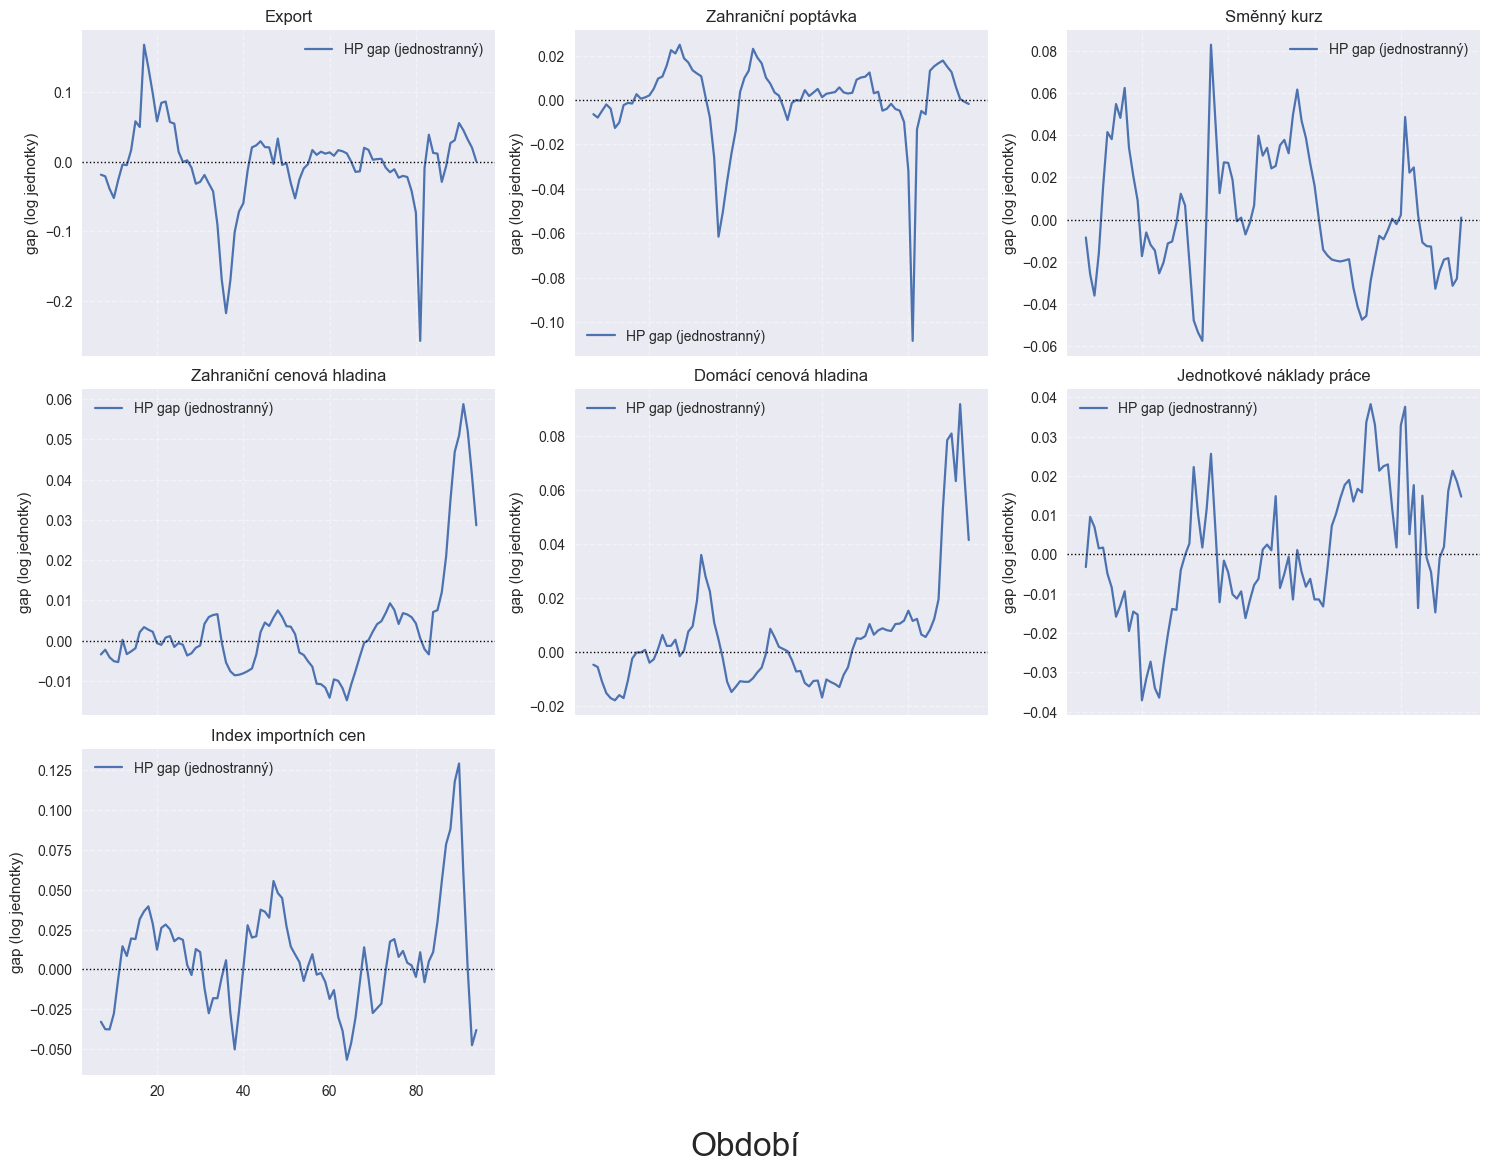

In [ ]:
# === Jednostranný (real-time) HP filtr + vizualizace gapů ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.filters.hp_filter import hpfilter

# --- Vstup: uprav podle sebe ---
variables = ["l_x", "l_y", "l_e", "l_p_for", "l_p_cz", "l_ulc", "l_m"]
HP_LAMBDA = 1600  # pro kvartální data

# --- Helper: jednostranný HP (expandující okno), vrací (gap, trend) zarovnané na index y ---
def hp_onesided(y: pd.Series, lamb: float = HP_LAMBDA, min_obs: int = 8):
    """
    Jednostranný HP: v čase t používá jen data do t (expandující okno).
    min_obs = kolik min. pozorování musí mít počáteční okno (ochrana před nesmysly na začátku).
    """
    y = y.astype(float)
    idx = y.index
    mask = y.notna()
    y_valid = y[mask]

    gap_1s  = pd.Series(np.nan, index=idx, name=y.name + "_gap_hp_1s" if y.name else "gap_hp_1s")
    trnd_1s = pd.Series(np.nan, index=idx, name=y.name + "_trnd_hp_1s" if y.name else "trnd_hp_1s")

    if y_valid.shape[0] < min_obs:
        return gap_1s, trnd_1s

    # expandující okno po valid indexech
    for k in range(min_obs, len(y_valid) + 1):
        window = y_valid.iloc[:k]
        cycle, trend = hpfilter(window, lamb=lamb)
        t_last = window.index[-1]
        gap_1s.loc[t_last]  = cycle.iloc[-1]
        trnd_1s.loc[t_last] = trend.iloc[-1]

    return gap_1s, trnd_1s

# --- Výpočet pro všechny proměnné ---
for var in variables:
    if var not in df.columns:
        raise KeyError(f"Chybí sloupec '{var}' v df.")
    gap_1s, trnd_1s = hp_onesided(df[var], lamb=HP_LAMBDA, min_obs=8)
    df[f"{var}_gap_hp_1s"]  = gap_1s
    df[f"{var}_trnd_hp_1s"] = trnd_1s

# --- Vizualizace: gapy z jednostranného HP v mřížce 3×3 ---
title_map = {
    "l_x": "Export",
    "l_y": "Zahraniční poptávka",
    "l_e": "Směnný kurz",
    "l_p_for": "Zahraniční cenová hladina",
    "l_p_cz": "Domácí cenová hladina",
    "l_ulc": "Jednotkové náklady práce",
    "l_m": "Index importních cen"
}

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
color_os = colors[0]  # barva pro jednostranný HP gap

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12), sharex=True)
axes = axes.flatten()

for i, var in enumerate(variables):
    col = f"{var}_gap_hp_1s"
    if col not in df.columns:
        raise KeyError(f"Chybí '{col}'.")
    ax = axes[i]
    ax.plot(df.index, df[col], label="HP gap (jednostranný)", linewidth=1.6, color=color_os)
    ax.axhline(0, linewidth=1.0, linestyle=":", color="black")
    ax.set_title(title_map.get(var, var), fontsize=12)
    ax.set_ylabel("gap (log jednotky)")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend()

# Odstranění dvou prázdných panelů (3x3 > 7 proměnných)
fig.delaxes(axes[-1])
fig.delaxes(axes[-2])

fig.text(0.5, 0.04, "Období", ha="center", va="center", fontsize=24)
plt.tight_layout()
plt.subplots_adjust(bottom=0.1)

# Volitelné uložení:
# import os
# os.makedirs("Obrázky", exist_ok=True)
# plt.savefig(os.path.join("Obrázky", "gapy_hp_jednostranny.png"), dpi=300, bbox_inches="tight")

plt.show()


In [ ]:
# === ADF test stacionarity pro gapy ===
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller

# Proměnné v bázi (uprav dle potřeby)
variables = ["l_x", "l_y", "l_e", "l_p_for", "l_p_cz", "l_ulc", "l_m"]

# Které gapy testovat (skript automaticky přeskočí ty, které v df nejsou)
suffixes = ["_gap", "_gap_hp", "_gap_hp_1s"]  # Hamilton, HP, HP (jednostranný)

alpha = 0.05  # hladina významnosti

results = []
for var in variables:
    for suf in suffixes:
        col = f"{var}{suf}"
        if col not in df.columns:
            continue
        s = pd.Series(df[col], dtype=float).dropna()
        if len(s) < 12:
            pval = np.nan
            note = "příliš málo dat"
            stationary = False
        else:
            try:
                # ADF nulová hypotéza: jednotkový kořen (nestacionární)
                adf_stat, pval, usedlag, nobs, crit, icbest = adfuller(s, autolag="AIC")
                stationary = (pval <= alpha)
                note = ""
            except Exception as e:
                pval = np.nan
                stationary = False
                note = f"chyba: {e}"

        results.append({
            "series": col,
            "p_value": pval,
            "stationary_at_5pct": stationary,
            "note": note
        })

res_df = pd.DataFrame(results).sort_values(["series"]).reset_index(drop=True)

# Rozdělení na stacionární vs. je třeba upravit
stationary_series = res_df.loc[res_df["stationary_at_5pct"] == True, "series"].tolist()
nonstationary_series = res_df.loc[(res_df["stationary_at_5pct"] == False) | (res_df["stationary_at_5pct"].isna()), "series"].tolist()

print("Tyto časové řady jsou stacionární:", ", ".join(stationary_series) if stationary_series else "(žádná)")
print("Tyto časové řády je třeba upravit:", ", ".join(nonstationary_series) if nonstationary_series else "(žádná)")

# Volitelně tabulka s p-hodnotami pro přehled
display(res_df)  # v Jupyteru


Tyto časové řady jsou stacionární: l_e_gap_hp, l_e_gap_hp_1s, l_m_gap_hp, l_m_gap_hp_1s, l_p_cz_gap_hp, l_ulc_gap_hp, l_x_gap, l_x_gap_hp, l_x_gap_hp_1s, l_y_gap, l_y_gap_hp, l_y_gap_hp_1s
Tyto časové řády je třeba upravit: l_e_gap, l_m_gap, l_p_cz_gap, l_p_cz_gap_hp_1s, l_p_for_gap, l_p_for_gap_hp, l_p_for_gap_hp_1s, l_ulc_gap, l_ulc_gap_hp_1s


,series,p_value,stationary_at_5pct,note
0,l_e_gap,0.109991,False,
1,l_e_gap_hp,0.000037,True,
2,l_e_gap_hp_1s,0.001570,True,
3,l_m_gap,0.161486,False,
4,l_m_gap_hp,0.000019,True,
5,l_m_gap_hp_1s,0.000407,True,
6,l_p_cz_gap,0.270183,False,
7,l_p_cz_gap_hp,0.008921,True,
8,l_p_cz_gap_hp_1s,0.866560,False,
9,l_p_for_gap,0.603477,False,


/opt/anaconda3/envs/data_analysis/lib/python3.12/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)
/opt/anaconda3/envs/data_analysis/lib/python3.12/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)
/opt/anaconda3/envs/data_analysis/lib/python3.12/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)


IndexError: index 9 is out of bounds for axis 0 with size 9

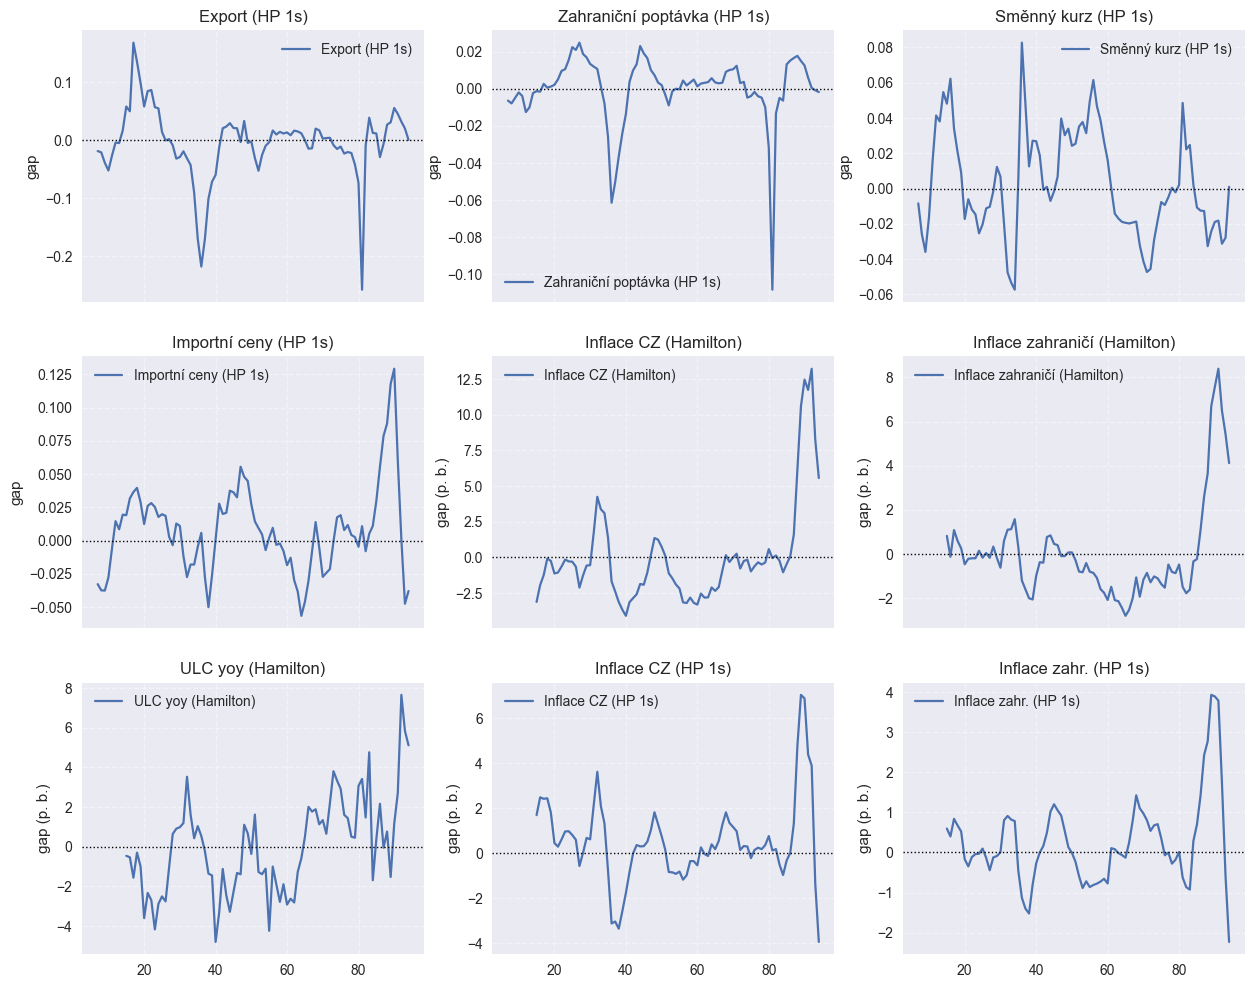

In [ ]:
# === 1) Transformace na meziroční log-diference (inflace, yoy-ULC) ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.filters.hp_filter import hpfilter

# Vstupy
vars_prices = ["l_p_cz", "l_p_for"]
var_ulc = "l_ulc"

# Inflace (y/y, v p.b.)
df["pi_cz"]  = 100 * (df["l_p_cz"]  - df["l_p_cz"].shift(4))
df["pi_for"] = 100 * (df["l_p_for"] - df["l_p_for"].shift(4))
# ULC yoy (p.b.)
df["ulc_yoy"] = 100 * (df["l_ulc"] - df["l_ulc"].shift(4))

# === 2) Hamiltonův filtr na yoy řady (h=8, p=4) ===
def hamilton_gap(y: pd.Series, h: int = 8, p: int = 4):
    y = y.astype(float)
    X = pd.concat(
        [pd.Series(1.0, index=y.index, name="const")] +
        [y.shift(h+i).rename(f"lag_{h+i}") for i in range(p)],
        axis=1
    )
    data = pd.concat([y.rename("y"), X], axis=1).dropna()
    if data.empty:
        return pd.Series(np.nan, index=y.index), pd.Series(np.nan, index=y.index)
    beta = np.linalg.lstsq(data.drop(columns=["y"]).to_numpy(), data["y"].to_numpy(), rcond=None)[0]
    fitted = X.dot(beta)
    gap = y - fitted
    invalid = X.isna().any(axis=1) | y.isna()
    gap[invalid] = np.nan
    fitted[invalid] = np.nan
    return gap, fitted

for name in ["pi_cz", "pi_for", "ulc_yoy"]:
    g, tr = hamilton_gap(df[name], h=8, p=4)
    df[f"{name}_gap"]  = g
    df[f"{name}_trnd"] = tr

# === 3) Volitelně: jednostranný HP gap (real-time) na yoy řady ===
HP_LAMBDA = 1600

def hp_onesided(y: pd.Series, lamb: float = HP_LAMBDA, min_obs: int = 12):
    y = y.astype(float)
    idx = y.index
    mask = y.notna()
    yv = y[mask]
    gap_1s  = pd.Series(np.nan, index=idx, name=y.name + "_gap_hp_1s")
    trnd_1s = pd.Series(np.nan, index=idx, name=y.name + "_trnd_hp_1s")
    if len(yv) < min_obs:
        return gap_1s, trnd_1s
    for k in range(min_obs, len(yv)+1):
        window = yv.iloc[:k]
        cyc, tr = hpfilter(window, lamb=lamb)
        t = window.index[-1]
        gap_1s.loc[t]  = cyc.iloc[-1]
        trnd_1s.loc[t] = tr.iloc[-1]
    return gap_1s, trnd_1s

for name in ["pi_cz", "pi_for", "ulc_yoy"]:
    g1s, t1s = hp_onesided(df[name], lamb=HP_LAMBDA, min_obs=12)
    df[f"{name}_gap_hp_1s"]  = g1s
    df[f"{name}_trnd_hp_1s"] = t1s

# === 4) Vizualizace: yoy Hamilton gapy (3x3 mřížka, doplníme i reálné proměnné, ať máš vše pohromadě) ===
variables_for_plot = [
    ("l_x_gap_hp_1s", "Export (HP 1s)"),
    ("l_y_gap_hp_1s", "Zahraniční poptávka (HP 1s)"),
    ("l_e_gap_hp_1s", "Směnný kurz (HP 1s)"),
    ("l_m_gap_hp_1s", "Importní ceny (HP 1s)"),
    ("pi_cz_gap",     "Inflace CZ (Hamilton)"),
    ("pi_for_gap",    "Inflace zahraničí (Hamilton)"),
    ("ulc_yoy_gap",   "ULC yoy (Hamilton)"),
    # volitelné: i HP 1s verze inflace/ULC, pokud je chceš porovnat:
    ("pi_cz_gap_hp_1s",  "Inflace CZ (HP 1s)"),
    ("pi_for_gap_hp_1s", "Inflace zahr. (HP 1s)"),
    ("ulc_yoy_gap_hp_1s","ULC yoy (HP 1s)"),
]

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12), sharex=True)
axes = axes.flatten()

for i, (col, ttl) in enumerate(variables_for_plot):
    ax = axes[i]
    if col not in df.columns:
        ax.set_visible(False)
        continue
    ax.plot(df.index, df[col], label=ttl, linewidth=1.6)
    ax.axhline(0, linewidth=1.0, linestyle=":", color="black")
    ax.set_title(ttl, fontsize=12)
    ax.set_ylabel("gap (p. b.)" if "pi_" in col or "ulc_yoy" in col else "gap")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend()

# skryj prázdné panely, pokud nějaké zbyly
for j in range(len(variables_for_plot), len(axes)):
    try:
        fig.delaxes(axes[j])
    except Exception:
        pass

fig.text(0.5, 0.04, "Období", ha="center", va="center", fontsize=24)
plt.tight_layout()
plt.subplots_adjust(bottom=0.1)
plt.show()


In [ ]:
# === PP test stacionarity (H0: jednotkový kořen = nestacionární) pro inflace/ULC gap ===
import numpy as np
import pandas as pd

# Primární cíle:
base_series = ["pi_cz_gap", "pi_for_gap", "ulc_yoy_gap"]
# Pokud existují i 1s-HP varianty, přidej je:
extra_series = ["pi_cz_gap_hp_1s", "pi_for_gap_hp_1s", "ulc_yoy_gap_hp_1s"]

to_test = [s for s in base_series if s in df.columns] + [s for s in extra_series if s in df.columns]
if not to_test:
    raise ValueError("V df nejsou žádné z očekávaných sloupců: pi_cz_gap, pi_for_gap, ulc_yoy_gap (případně *_gap_hp_1s).")

# Zkus Phillips–Perron; pokud není k dispozici, spadne na ADF (stejná H0: jednotkový kořen)
pp_available = True
try:
    from statsmodels.tsa.stattools import phillips_perron
except Exception:
    pp_available = False
from statsmodels.tsa.stattools import adfuller

alpha = 0.05
results = []
for col in to_test:
    s = pd.Series(df[col], dtype=float).dropna()
    if len(s) < 12:
        results.append({"series": col, "test": "PP" if pp_available else "ADF",
                        "p_value": np.nan, "stationary_at_5pct": False, "note": "příliš málo dat"})
        continue
    try:
        if pp_available:
            stat, pval, usedlag, nobs = phillips_perron(s)
        else:
            # fallback: ADF má stejnou H0 (jednotkový kořen) – rozhodovací pravidlo identické
            adf_stat, pval, usedlag, nobs, crit, icbest = adfuller(s, autolag="AIC")
        stationary = (pval <= alpha)  # p ≤ 0.05 => zamítáme H0 => stacionární
        results.append({"series": col, "test": "PP" if pp_available else "ADF",
                        "p_value": float(pval), "stationary_at_5pct": bool(stationary), "note": ""})
    except Exception as e:
        results.append({"series": col, "test": "PP" if pp_available else "ADF",
                        "p_value": np.nan, "stationary_at_5pct": False, "note": f"chyba: {e}"})

res_df = pd.DataFrame(results).sort_values("series").reset_index(drop=True)

# Výstup v požadovaném formátu:
stationary_series = res_df.loc[res_df["stationary_at_5pct"] == True, "series"].tolist()
nonstationary_series = res_df.loc[(res_df["stationary_at_5pct"] == False) | (res_df["stationary_at_5pct"].isna()), "series"].tolist()

print("Tyto časové řady jsou stacionární:", ", ".join(stationary_series) if stationary_series else "(žádná)")
print("Tyto časové řády je třeba upravit:", ", ".join(nonstationary_series) if nonstationary_series else "(žádná)")

# Volitelně: přehled p-hodnot
# display(res_df)


Tyto časové řady jsou stacionární: pi_cz_gap_hp_1s, ulc_yoy_gap_hp_1s
Tyto časové řády je třeba upravit: pi_cz_gap, pi_for_gap, pi_for_gap_hp_1s, ulc_yoy_gap


In [ ]:
import numpy as np
import pandas as pd

# 1) Test: PP (H0: nestacionární). Fallback na ADF se stejnou H0.
try:
    from statsmodels.tsa.stattools import phillips_perron
    PP_AVAILABLE = True
except Exception:
    from statsmodels.tsa.stattools import adfuller
    PP_AVAILABLE = False

def is_stationary(series: pd.Series, alpha=0.05) -> bool:
    s = pd.Series(series, dtype=float).dropna()
    if len(s) < 20:
        return False
    try:
        if PP_AVAILABLE:
            stat, pval, usedlag, nobs = phillips_perron(s)
        else:
            adf_stat, pval, usedlag, nobs, crit, icbest = adfuller(s, autolag="AIC")
        return bool(pval <= alpha)
    except Exception:
        return False

# 2) Jednostranný HP
from statsmodels.tsa.filters.hp_filter import hpfilter

def hp_onesided(y: pd.Series, lamb: float, min_obs: int = 12):
    y = y.astype(float)
    idx = y.index
    mask = y.notna()
    yv = y[mask]
    gap_1s  = pd.Series(np.nan, index=idx)
    trnd_1s = pd.Series(np.nan, index=idx)
    if len(yv) < min_obs:
        return gap_1s, trnd_1s
    for k in range(min_obs, len(yv)+1):
        window = yv.iloc[:k]
        cyc, tr = hpfilter(window, lamb=lamb)
        t = window.index[-1]
        gap_1s.loc[t]  = cyc.iloc[-1]
        trnd_1s.loc[t] = tr.iloc[-1]
    return gap_1s, trnd_1s

# 3) Christiano–Fitzgerald band-pass (6–32Q) – cyklus
from statsmodels.tsa.filters.cf_filter import cffilter

def cf_cycle(y: pd.Series, low=6, high=32):
    # Vrací cycle (dvoustranný), trend
    cycle, trend = cffilter(pd.Series(y, dtype=float), low=low, high=high, drift=False)
    return cycle, trend

# ==== KONFIG ====
INFL_TARGET_FOR = 2.0   # zahraniční inflační cíl v p.b.; uprav dle potřeby
HP_GRID = [1600, 6400, 10000]
BANDPASS = (6, 32)      # kvartály
ALPHA = 0.05

# ==== VSTUPNÍ SLOUPCE (očekává se, že existují) ====
# pi_for = 100 * (l_p_for - l_p_for.shift(4))
# ulc_yoy = 100 * (l_ulc - l_ulc.shift(4))
needed = []
if "pi_for" not in df.columns:
    needed.append("pi_for (yoy zahraniční inflace)")
if "ulc_yoy" not in df.columns:
    needed.append("ulc_yoy (yoy růst ULC)")
if needed:
    raise KeyError("Chybí: " + ", ".join(needed))

selection = {}

# ====== Zahraniční inflace ======
# 0) Target gap: pi_for - target
df["pi_for_gap_target"] = df["pi_for"] - INFL_TARGET_FOR
if is_stationary(df["pi_for_gap_target"], alpha=ALPHA):
    selection["pi_for"] = ("pi_for_gap_target", "target gap (pi - {:.1f}%)".format(INFL_TARGET_FOR))
else:
    # 1) HP 1s s gridem lambda
    chosen = None
    for lam in HP_GRID:
        g1s, t1s = hp_onesided(df["pi_for"], lamb=lam, min_obs=12)
        name = f"pi_for_gap_hp_1s_l{lam}"
        df[name] = g1s
        if is_stationary(df[name], alpha=ALPHA):
            chosen = (name, f"HP 1s (lambda={lam})")
            break
    if chosen is not None:
        selection["pi_for"] = chosen
    else:
        # 2) CF band-pass 6–32Q
        cyc, tr = cf_cycle(df["pi_for"], low=BANDPASS[0], high=BANDPASS[1])
        df["pi_for_gap_cf"] = cyc
        if is_stationary(df["pi_for_gap_cf"], alpha=ALPHA):
            selection["pi_for"] = ("pi_for_gap_cf", f"CF band-pass {BANDPASS[0]}–{BANDPASS[1]}Q")
        else:
            # 3) fallback – quarterly místo yoy + HP 1s
            df["pi_for_qoq"] = df["l_p_for"].diff() * 100
            g1s, _ = hp_onesided(df["pi_for_qoq"], lamb=1600, min_obs=12)
            df["pi_for_qoq_gap_hp_1s"] = g1s
            if is_stationary(df["pi_for_qoq_gap_hp_1s"], alpha=ALPHA):
                selection["pi_for"] = ("pi_for_qoq_gap_hp_1s", "q/q log-chg + HP 1s (1600)")
            else:
                selection["pi_for"] = (None, "nic neprošlo – zvaž strukturální očištění (VAT/energy dummies) a opakuj")

# ====== ULC yoy ======
# už máš stacionární ulc_yoy_gap_hp_1s; jen ověříme a případně nabídneme alternativu
if "ulc_yoy_gap_hp_1s" in df.columns and is_stationary(df["ulc_yoy_gap_hp_1s"], alpha=ALPHA):
    selection["ulc_yoy"] = ("ulc_yoy_gap_hp_1s", "HP 1s (1600) – stávající, stacionární")
else:
    # zkus target gap (např. nulový dlouhodobý růst – 0), HP grid a CF
    df["ulc_yoy_gap_target"] = df["ulc_yoy"] - 0.0
    if is_stationary(df["ulc_yoy_gap_target"], alpha=ALPHA):
        selection["ulc_yoy"] = ("ulc_yoy_gap_target", "target gap (0%)")
    else:
        chosen = None
        for lam in HP_GRID:
            g1s, _ = hp_onesided(df["ulc_yoy"], lamb=lam, min_obs=12)
            name = f"ulc_yoy_gap_hp_1s_l{lam}"
            df[name] = g1s
            if is_stationary(df[name], alpha=ALPHA):
                chosen = (name, f"HP 1s (lambda={lam})")
                break
        if chosen is not None:
            selection["ulc_yoy"] = chosen
        else:
            cyc, tr = cf_cycle(df["ulc_yoy"], low=BANDPASS[0], high=BANDPASS[1])
            df["ulc_yoy_gap_cf"] = cyc
            if is_stationary(df["ulc_yoy_gap_cf"], alpha=ALPHA):
                selection["ulc_yoy"] = ("ulc_yoy_gap_cf", f"CF band-pass {BANDPASS[0]}–{BANDPASS[1]}Q")
            else:
                selection["ulc_yoy"] = (None, "nic neprošlo – zvaž quarterly změny a/s nebo strukturální očištění")

# ====== Domácí inflace ======
# už máš stacionární pi_cz_gap_hp_1s; formalizujeme výběr
if "pi_cz_gap_hp_1s" in df.columns and is_stationary(df["pi_cz_gap_hp_1s"], alpha=ALPHA):
    selection["pi_cz"] = ("pi_cz_gap_hp_1s", "HP 1s (1600) – stávající, stacionární")
else:
    # pro úplnost stejný postup jako u pi_for
    df["pi_cz_gap_target"] = df["pi_cz"] - 2.0
    if is_stationary(df["pi_cz_gap_target"], alpha=ALPHA):
        selection["pi_cz"] = ("pi_cz_gap_target", "target gap (pi - 2%)")
    else:
        chosen = None
        for lam in HP_GRID:
            g1s, _ = hp_onesided(df["pi_cz"], lamb=lam, min_obs=12)
            name = f"pi_cz_gap_hp_1s_l{lam}"
            df[name] = g1s
            if is_stationary(df[name], alpha=ALPHA):
                chosen = (name, f"HP 1s (lambda={lam})")
                break
        if chosen is not None:
            selection["pi_cz"] = chosen
        else:
            cyc, tr = cf_cycle(df["pi_cz"], low=BANDPASS[0], high=BANDPASS[1])
            df["pi_cz_gap_cf"] = cyc
            if is_stationary(df["pi_cz_gap_cf"], alpha=ALPHA):
                selection["pi_cz"] = ("pi_cz_gap_cf", f"CF band-pass {BANDPASS[0]}–{BANDPASS[1]}Q")
            else:
                selection["pi_cz"] = (None, "nic neprošlo – revize transformací")

# ---- Report ----
print("Výběr stacionárních gapů:")
for key in ["pi_cz", "pi_for", "ulc_yoy"]:
    name, how = selection.get(key, (None, "nezjištěno"))
    print(f"  {key}:  {name}  [{how}]")


/opt/anaconda3/envs/data_analysis/lib/python3.12/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)
/opt/anaconda3/envs/data_analysis/lib/python3.12/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)


Výběr stacionárních gapů:
  pi_cz:  pi_cz_gap_hp_1s  [HP 1s (1600) – stávající, stacionární]
  pi_for:  pi_for_qoq_gap_hp_1s  [q/q log-chg + HP 1s (1600)]
  ulc_yoy:  ulc_yoy_gap_hp_1s  [HP 1s (1600) – stávající, stacionární]


/opt/anaconda3/envs/data_analysis/lib/python3.12/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)
/opt/anaconda3/envs/data_analysis/lib/python3.12/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)


In [ ]:
# Standardizace názvů pro model
final_map = {
    "l_x_gap_final":        "l_x_gap_hp_1s",
    "l_y_gap_final":        "l_y_gap_hp_1s",
    "l_e_gap_final":        "l_e_gap_hp_1s",
    "l_m_gap_final":        "l_m_gap_hp_1s",
    "pi_cz_gap_final":      "pi_cz_gap_hp_1s",
    "pi_for_gap_final":     "pi_for_qoq_gap_hp_1s",
    "ulc_gap_final":        "ulc_yoy_gap_hp_1s",
}

for new, old in final_map.items():
    if old not in df.columns:
        raise KeyError(f"Chybí zdrojový sloupec: {old}")
    df[new] = df[old]

# (volitelně) vytvoř si čistý dataset pro odhad:
model_cols = list(final_map.keys())
df_model = df[model_cols].dropna()   # nebo použij chytrou imputaci, ale raději buď striktní
print(df_model.columns.tolist())
print(df_model.shape)


['l_x_gap_final', 'l_y_gap_final', 'l_e_gap_final', 'l_m_gap_final', 'pi_cz_gap_final', 'pi_for_gap_final', 'ulc_gap_final']
(80, 7)


In [ ]:
# === Sjednocení metodiky: obě inflace jako q/q + HP jednostranný ===
import numpy as np
import pandas as pd

# 1) q/q inflace (v p. b.) z log hladin
df["pi_cz_qoq"]  = 100 * (df["l_p_cz"]  - df["l_p_cz"].shift(1))
df["pi_for_qoq"] = 100 * (df["l_p_for"] - df["l_p_for"].shift(1))

# 2) Jednostranný HP filtr
from statsmodels.tsa.filters.hp_filter import hpfilter

def hp_onesided(y: pd.Series, lamb: float, min_obs: int = 12):
    y = y.astype(float)
    idx = y.index
    mask = y.notna()
    yv = y[mask]
    gap_1s  = pd.Series(np.nan, index=idx)
    trnd_1s = pd.Series(np.nan, index=idx)
    if len(yv) < min_obs:
        return gap_1s, trnd_1s
    for k in range(min_obs, len(yv)+1):
        window = yv.iloc[:k]
        cyc, tr = hpfilter(window, lamb=lamb)
        t = window.index[-1]
        gap_1s.loc[t]  = cyc.iloc[-1]
        trnd_1s.loc[t] = tr.iloc[-1]
    return gap_1s, trnd_1s

# 3) PP test (H0: nestacionární). Fallback ADF (stejná H0).
try:
    from statsmodels.tsa.stattools import phillips_perron
    PP_AVAILABLE = True
except Exception:
    from statsmodels.tsa.stattools import adfuller
    PP_AVAILABLE = False

def is_stationary(series: pd.Series, alpha=0.05) -> bool:
    s = pd.Series(series, dtype=float).dropna()
    if len(s) < 20:
        return False
    try:
        if PP_AVAILABLE:
            stat, pval, usedlag, nobs = phillips_perron(s)
        else:
            adf_stat, pval, usedlag, nobs, crit, icbest = adfuller(s, autolag="AIC")
        return bool(pval <= alpha)
    except Exception:
        return False

# 4) Vyber první stacionární verzi z gridu lambd
def pick_stationary_hp1s(y: pd.Series, name: str, lambdas=(1600, 6400, 10000)):
    chosen = None
    for lam in lambdas:
        g1s, t1s = hp_onesided(y, lamb=lam, min_obs=12)
        col = f"{name}_gap_hp_1s_l{lam}"
        df[col] = g1s
        if is_stationary(df[col]):
            chosen = (col, lam)
            break
    return chosen  # (column_name, lambda) or None

# 5) Aplikace na obě inflace
cz_sel  = pick_stationary_hp1s(df["pi_cz_qoq"],  "pi_cz_qoq")
for_sel = pick_stationary_hp1s(df["pi_for_qoq"], "pi_for_qoq")

if cz_sel is None or for_sel is None:
    msg = []
    if cz_sel is None:  msg.append("pi_cz_qoq: nic neprošlo (zkus jinou transformaci nebo očistit outliery).")
    if for_sel is None: msg.append("pi_for_qoq: nic neprošlo (zkus jinou transformaci nebo očistit outliery).")
    raise RuntimeError(" / ".join(msg))

(pi_cz_col,  lam_cz)  = cz_sel
(pi_for_col, lam_for) = for_sel

# 6) Nastav finální aliasy, aby byly konzistentní a porovnatelné
df["pi_cz_gap_final"]  = df[pi_cz_col]
df["pi_for_gap_final"] = df[pi_for_col]

print("Sjednocená metodika (q/q + HP 1s):")
print(f"  pi_cz_gap_final  = {pi_cz_col}  (λ = {lam_cz})")
print(f"  pi_for_gap_final = {pi_for_col} (λ = {lam_for})")

# (volitelně) rychlá kontrola stacionarity:
print("Stacionární (PP/ADF rozhodnutí):",
      is_stationary(df['pi_cz_gap_final']), is_stationary(df['pi_for_gap_final']))


Sjednocená metodika (q/q + HP 1s):
  pi_cz_gap_final  = pi_cz_qoq_gap_hp_1s_l1600  (λ = 1600)
  pi_for_gap_final = pi_for_qoq_gap_hp_1s_l1600 (λ = 1600)
Stacionární (PP/ADF rozhodnutí): True True


/opt/anaconda3/envs/data_analysis/lib/python3.12/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)
/opt/anaconda3/envs/data_analysis/lib/python3.12/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)
/var/folders/1b/x_b0byr51fz1qtfy12vcgbkm0000gn/T/ipykernel_84270/1845601586.py:56: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col] = g1s


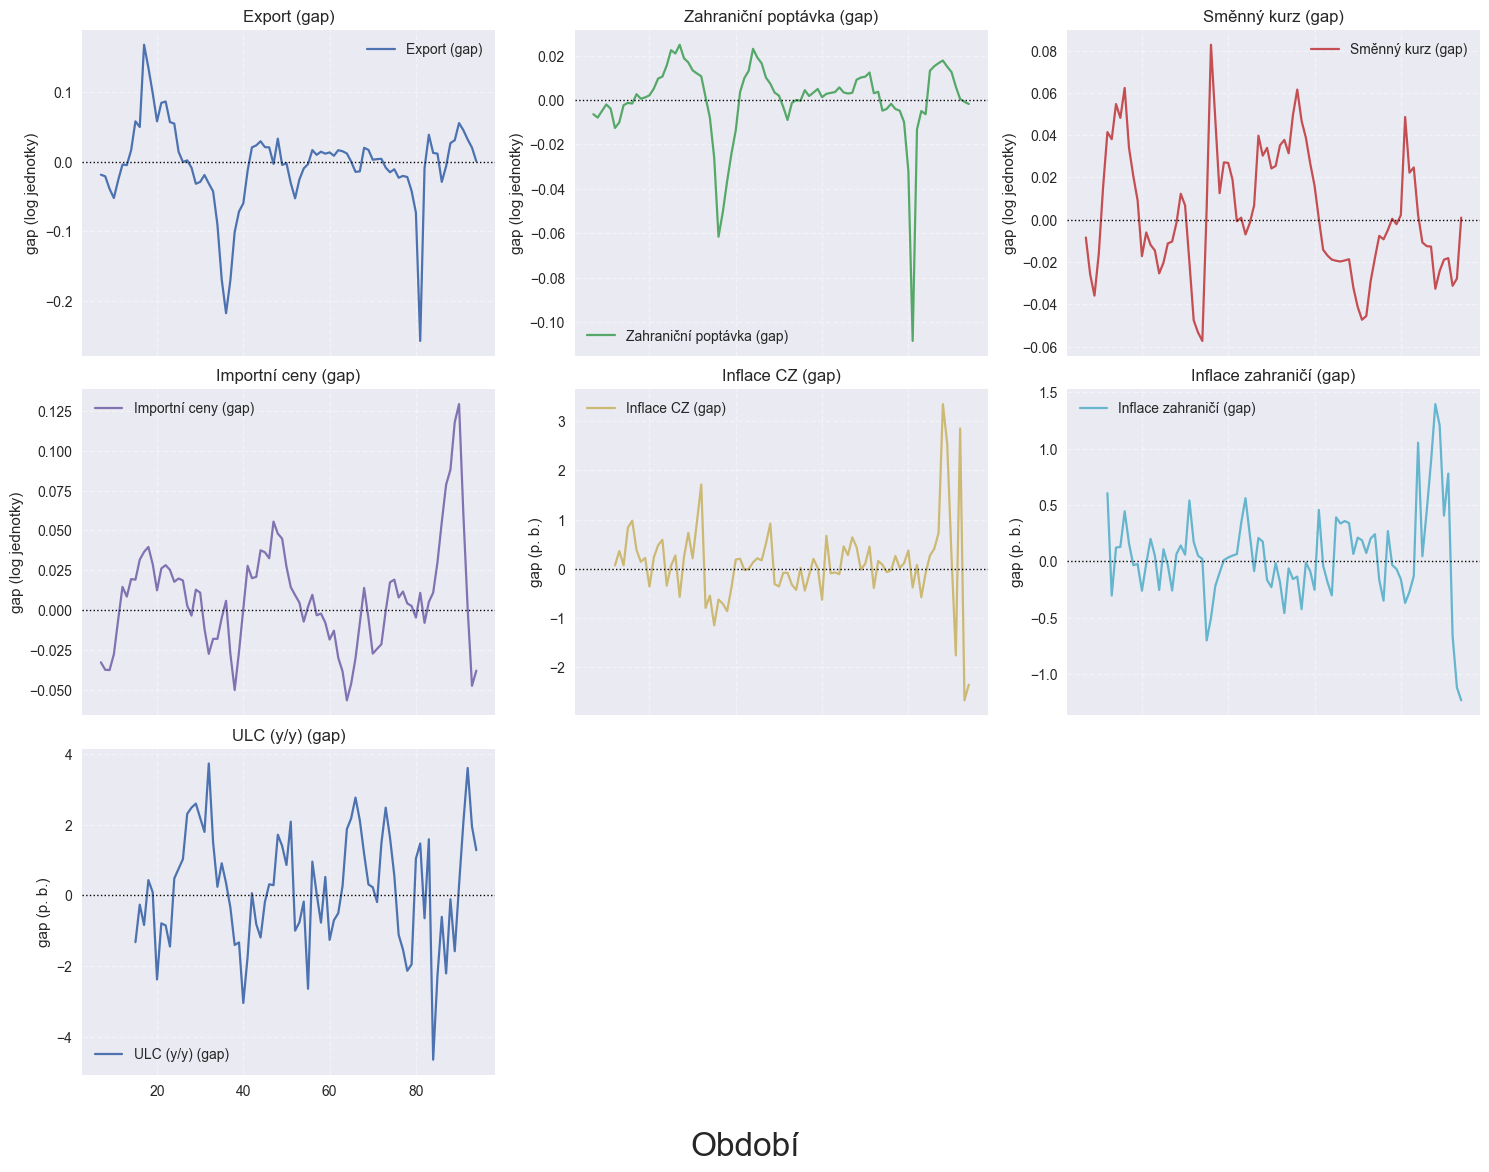

In [ ]:
# Vizualizace finálních gapů pro model (3x3 mřížka) – robustní verze
import matplotlib.pyplot as plt
import numpy as np

# Očekává se, že už máš v df tyto sloupce (pokud nějaký chybí, panel se přeskočí):
final_vars = [
    "l_x_gap_final",
    "l_y_gap_final",
    "l_e_gap_final",
    "l_m_gap_final",
    "pi_cz_gap_final",
    "pi_for_gap_final",
    "ulc_gap_final",
]

title_map = {
    "l_x_gap_final":   "Export (gap)",
    "l_y_gap_final":   "Zahraniční poptávka (gap)",
    "l_e_gap_final":   "Směnný kurz (gap)",
    "l_m_gap_final":   "Importní ceny (gap)",
    "pi_cz_gap_final": "Inflace CZ (gap)",
    "pi_for_gap_final":"Inflace zahraničí (gap)",
    "ulc_gap_final":   "ULC (y/y) (gap)",
}

def infer_method_label(colname: str) -> str:
    """
    Z názvu sloupce (nebo aliasů, pokud sis je nechal) zkusí vytáhnout info o metodě.
    Pokud nelze odhadnout, vrací prázdný řetězec.
    """
    name = colname.lower()
    # HP jednostranný + lambda kódovaná v aliasu (např. *_l1600)
    if "hp" in name or "hp_1s" in name:
        # pokus o λ z názvu
        import re
        m = re.search(r"_l(\d{3,5})", name)
        if m:
            return f"HP 1s (λ={m.group(1)})"
        return "HP 1s"
    if "hamilton" in name:
        return "Hamilton"
    return ""  # nevíme

def ylabel_for(colname: str) -> str:
    # inflace a ULC v p. b., ostatní log gap
    if any(k in colname for k in ["pi_cz", "pi_for", "ulc"]):
        return "gap (p. b.)"
    return "gap (log jednotky)"

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12), sharex=True)
axes = axes.flatten()

drawn = 0
for i, col in enumerate(final_vars):
    ax = axes[i]
    if col not in df.columns:
        ax.set_visible(False)
        continue

    s = df[col].astype(float)
    # pokud samé NaN, panel skryj
    if s.dropna().empty:
        ax.set_visible(False)
        continue

    method_lbl = infer_method_label(col)
    base_title = title_map.get(col, col)
    ttl = f"{base_title}" + (f" — {method_lbl}" if method_lbl else "")

    ax.plot(df.index, s, label=ttl, color=colors[i % len(colors)], linewidth=1.6)
    ax.axhline(0.0, color="black", linewidth=1.0, linestyle=":")

    # hezčí y popisek podle typu proměnné
    ax.set_ylabel(ylabel_for(col))
    ax.set_title(ttl, fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend()
    drawn += 1

# Skryj nepoužité panely (nepředpokládej fixně 2 prázdné)
for j in range(len(final_vars), len(axes)):
    try:
        fig.delaxes(axes[j])
    except Exception:
        pass

fig.text(0.5, 0.04, "Období", ha="center", va="center", fontsize=24)
plt.tight_layout()
plt.subplots_adjust(bottom=0.1)

# Volitelné uložení:
# import os
# os.makedirs("Obrázky", exist_ok=True)
# plt.savefig(os.path.join("Obrázky", "final_gaps.png"), dpi=300, bbox_inches="tight")

if drawn == 0:
    raise RuntimeError("Nebyl vykreslen žádný panel – zkontroluj, zda existují *_gap_final sloupce a nejsou celé NaN.")
plt.show()


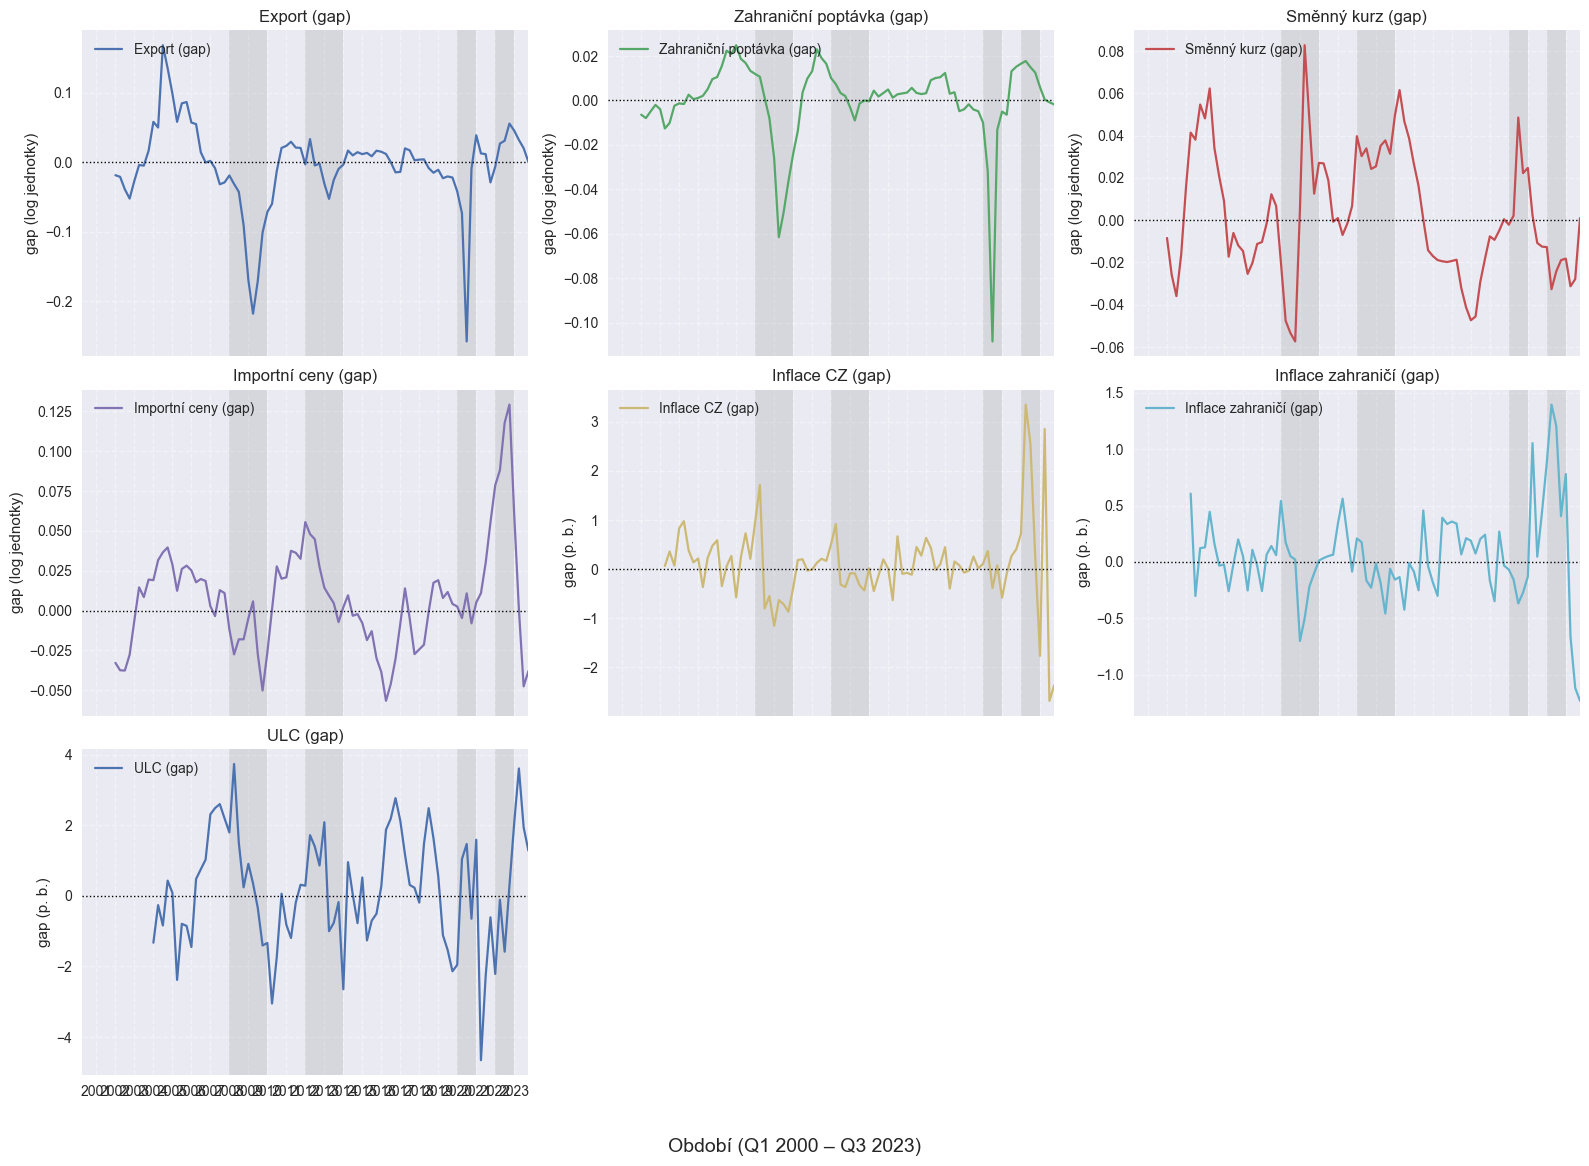

In [ ]:
# Robustní vizualizace s časovou osou 2000Q1–2023Q3 + recese
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

final_vars = [
    "l_x_gap_final",
    "l_y_gap_final",
    "l_e_gap_final",
    "l_m_gap_final",
    "pi_cz_gap_final",
    "pi_for_gap_final",
    "ulc_gap_final",
]

title_map = {
    "l_x_gap_final":   "Export (gap)",
    "l_y_gap_final":   "Zahraniční poptávka (gap)",
    "l_e_gap_final":   "Směnný kurz (gap)",
    "l_m_gap_final":   "Importní ceny (gap)",
    "pi_cz_gap_final": "Inflace CZ (gap)",
    "pi_for_gap_final":"Inflace zahraničí (gap)",
    "ulc_gap_final":   "ULC (gap)",
}

# --- 0) Cílový kvartální index ---
target_period_index = pd.period_range("2000Q1", "2023Q3", freq="Q")
target_dt_index = target_period_index.to_timestamp(how="end")  # kreslit na konci kvartálu (můžeš změnit na "start")

# --- 1) Získání časového indexu z df ---
df_work = df.copy()

def coerce_to_quarterly_index(df_):
    # a) pokud už je PeriodIndex s kvartály
    if isinstance(df_.index, pd.PeriodIndex) and df_.index.freqstr and df_.index.freqstr.upper().startswith("Q"):
        return df_.index

    # b) pokud je PeriodIndex bez freq, zkusíme nastavit freq na Q
    if isinstance(df_.index, pd.PeriodIndex):
        try:
            return df_.index.asfreq("Q")
        except Exception:
            pass

    # c) pokud je DatetimeIndex -> převést na PeriodIndex Q
    if isinstance(df_.index, pd.DatetimeIndex):
        return df_.index.to_period("Q")

    # d) pokud existuje sloupec 'date'
    for cand in ["date", "Date", "DATE", "datum", "Datum"]:
        if cand in df_.columns:
            s = df_[cand]
            # zkus Q periodu (formáty typu '2000Q1'); když ne, tak to_datetime a na Q
            try:
                per = pd.PeriodIndex(s.astype(str), freq="Q")
                return per
            except Exception:
                try:
                    dt = pd.to_datetime(s)
                    return dt.to_period("Q")
                except Exception:
                    pass

    # e) fallback: vytvoř kvartální osu od 2000Q1 podle délky df
    # (lepší než RangeIndex; ale varujeme)
    fallback = pd.period_range("2000Q1", periods=len(df_), freq="Q")
    print("Upozornění: Nebyl nalezen časový index ani 'date'; přiřazuji kvartální osu od 2000Q1 podle délky dat.")
    return fallback

per_index = coerce_to_quarterly_index(df_work)
df_work.index = per_index

# --- 2) Reindex na přesně 2000Q1–2023Q3 (zachová existující data, jinak NaN) ---
df_q = df_work.reindex(target_period_index)

# --- 3) Převod na DatetimeIndex pro matplotlib ---
df_plot = df_q.copy()
df_plot.index = target_dt_index  # period-end; pro period-start: .to_timestamp("start")

# --- 4) Definice recesních období (Datetime) ---
recessions = [
    (pd.Timestamp("2008-01-01"), pd.Timestamp("2009-12-31"), "2008–2009"),
    (pd.Timestamp("2012-01-01"), pd.Timestamp("2013-12-31"), "2012–2013"),
    (pd.Timestamp("2020-01-01"), pd.Timestamp("2020-12-31"), "2020"),
    (pd.Timestamp("2022-01-01"), pd.Timestamp("2022-12-31"), "2022"),
]

# --- 5) Kreslení ---
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12), sharex=True)
axes = axes.flatten()

for i, col in enumerate(final_vars):
    ax = axes[i]
    if col not in df_plot.columns:
        ax.set_visible(False)
        continue

    s = pd.to_numeric(df_plot[col], errors="coerce")
    if s.dropna().empty:
        ax.set_visible(False)
        continue

    ax.plot(df_plot.index, s.values, label=title_map.get(col, col), color=colors[i % len(colors)], linewidth=1.6)
    ax.axhline(0.0, color="black", linewidth=1.0, linestyle=":")

    # stínování recesí
    for (t0, t1, lab) in recessions:
        ax.axvspan(t0, t1, color="grey", alpha=0.18, lw=0)

    ax.set_title(title_map.get(col, col), fontsize=12)
    # Y-osa: p.b. pro inflace/ULC, jinak log-jednotky
    if any(k in col for k in ["pi_cz", "pi_for", "ulc"]):
        ax.set_ylabel("gap (p. b.)")
    else:
        ax.set_ylabel("gap (log jednotky)")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(loc="upper left")

    # časová osa 2000–2023, roční hlavní tick + kvartální minor tick
    ax.set_xlim([df_plot.index.min(), df_plot.index.max()])
    ax.xaxis.set_major_locator(mdates.YearLocator(base=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[3,6,9,12]))

# skryj zbylé panely (3x3 > 7)
for j in range(len(final_vars), len(axes)):
    try:
        fig.delaxes(axes[j])
    except Exception:
        pass

fig.text(0.5, 0.04, "Období (Q1 2000 – Q3 2023)", ha="center", va="center", fontsize=14)
plt.tight_layout()
plt.subplots_adjust(bottom=0.1)
plt.show()


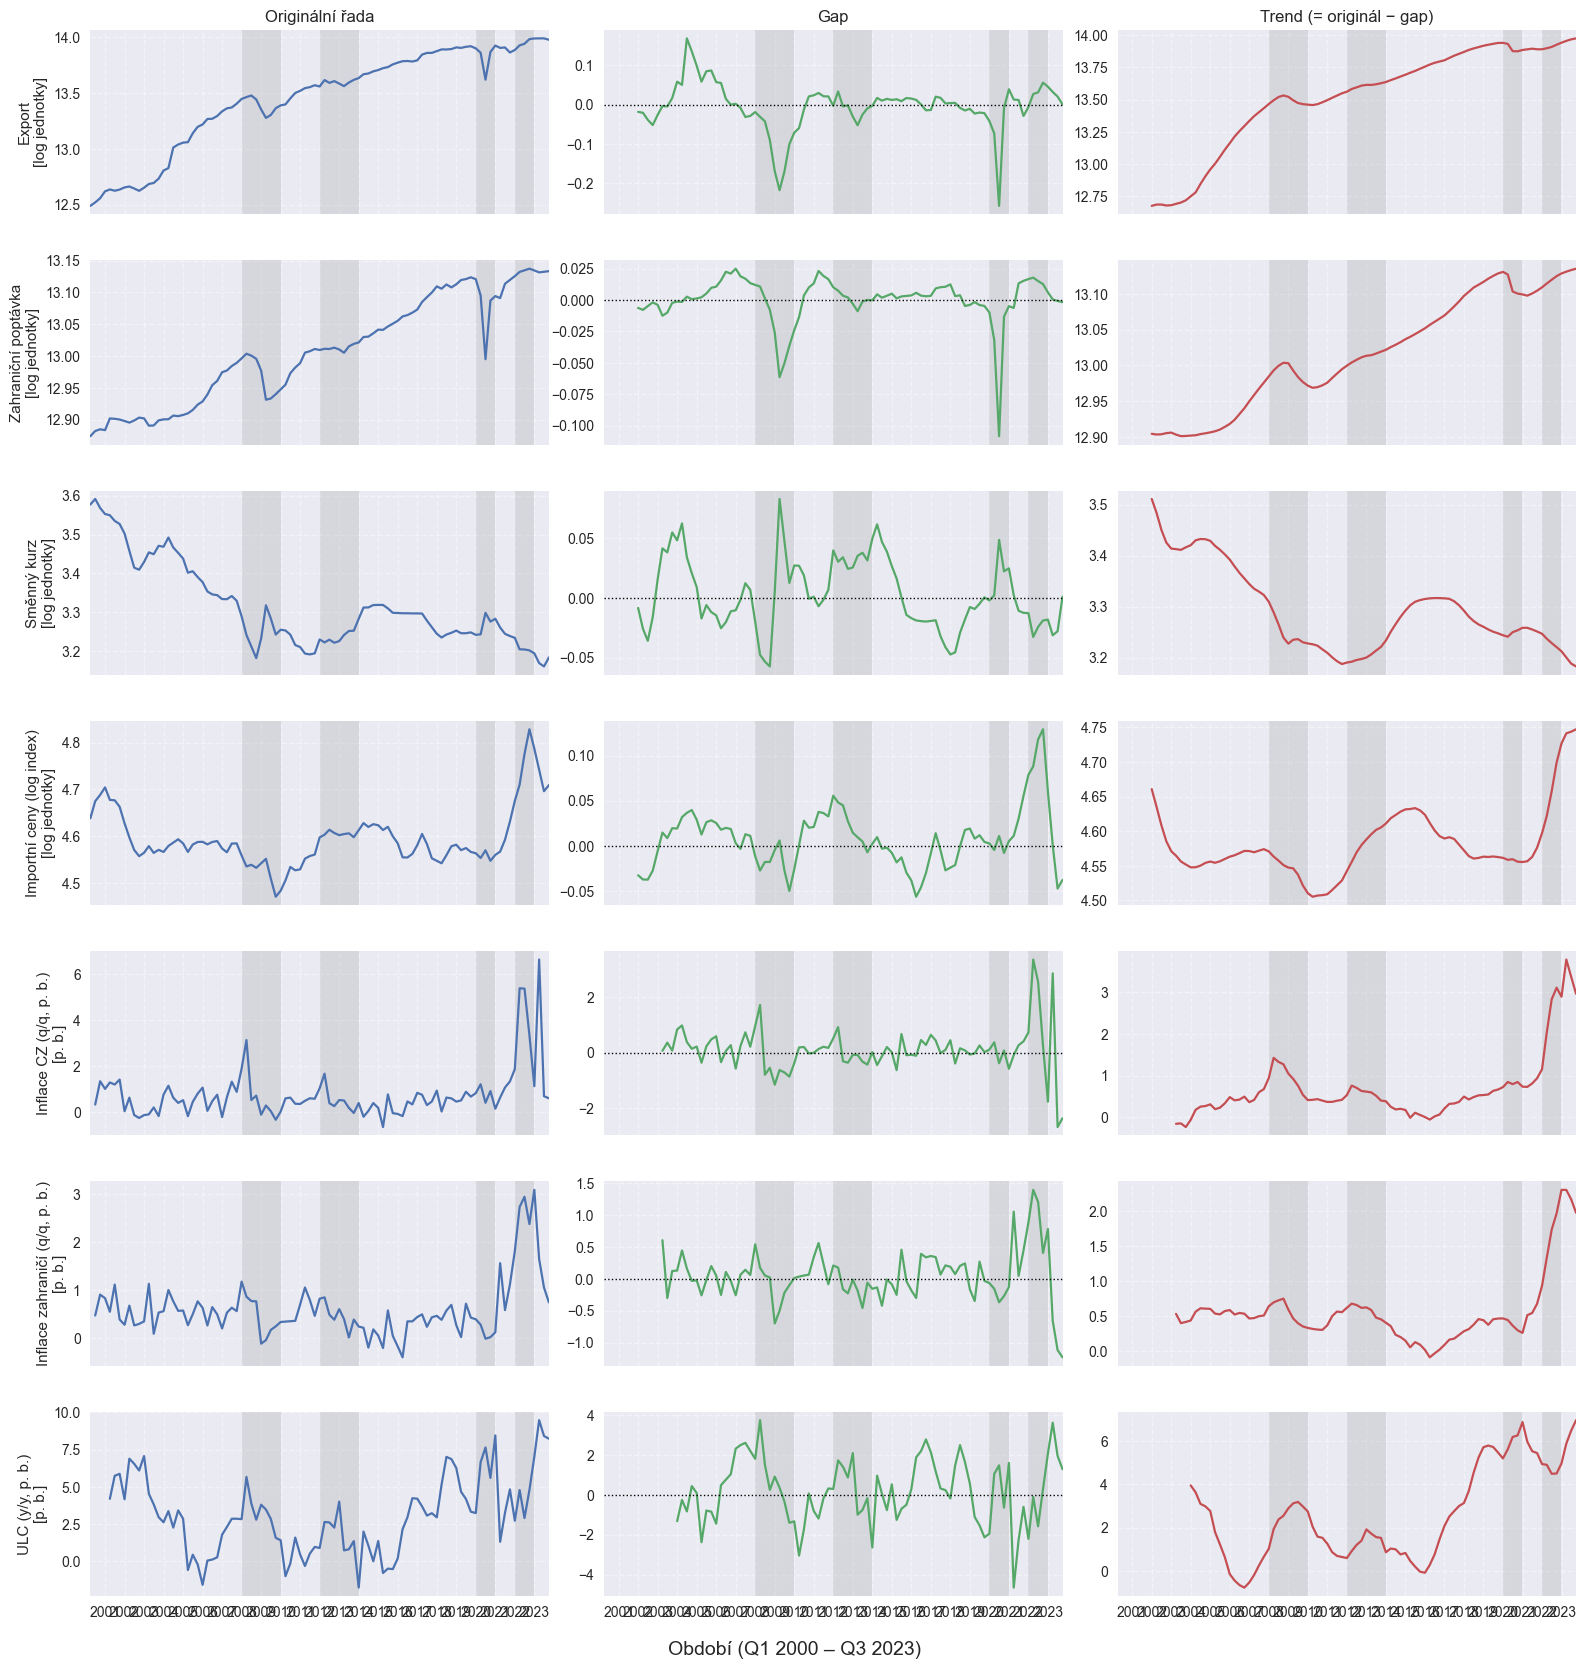

In [ ]:
# 7×3: (řádky = proměnné) × (sloupce = Originál | Gap | Trend), s vyznačením recesí
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- finální gapy (aliasy) ---
final_gaps = {
    "l_x": "l_x_gap_final",
    "l_y": "l_y_gap_final",
    "l_e": "l_e_gap_final",
    "l_m": "l_m_gap_final",
    # inflace/ULC: originál je transformace, aby platilo 'trend = originál - gap'
    "pi_cz":  "pi_cz_gap_final",   # očekává se, že vznikl z pi_cz_qoq
    "pi_for": "pi_for_gap_final",  # očekává se, že vznikl z pi_for_qoq
    "ulc":    "ulc_gap_final",     # očekává se, že vznikl z ulc_yoy
}

# --- mapování názvů na "originál" (z čeho byl gap) ---
# (u reálných proměnných je originál rovnou l_*; u inflací/ULC použijeme qoq/yoy transformace)
origin_map_candidates = {
    "l_x":   ["l_x"],
    "l_y":   ["l_y"],
    "l_e":   ["l_e"],
    "l_m":   ["l_m"],
    "pi_cz": ["pi_cz_qoq", "pi_cz"],      # preferuj qoq; fallback pi_cz (y/y), pokud qoq není
    "pi_for":["pi_for_qoq", "pi_for"],    # preferuj qoq; fallback pi_for (y/y)
    "ulc":   ["ulc_yoy"],                 # yoy jako zdroj pro ulc gap
}

# --- popisky panelů ---
row_title = {
    "l_x":   "Export",
    "l_y":   "Zahraniční poptávka",
    "l_e":   "Směnný kurz",
    "l_m":   "Importní ceny (log index)",
    "pi_cz": "Inflace CZ (q/q, p. b.)",
    "pi_for":"Inflace zahraničí (q/q, p. b.)",
    "ulc":   "ULC (y/y, p. b.)",
}

# --- 1) Zajisti kvartální časový index 2000Q1–2023Q3 ---
target_period_index = pd.period_range("2000Q1", "2023Q3", freq="Q")
target_dt_index = target_period_index.to_timestamp(how="end")

df_work = df.copy()

def coerce_to_quarterly_index(df_):
    if isinstance(df_.index, pd.PeriodIndex) and (df_.index.freqstr or "").upper().startswith("Q"):
        return df_.index
    if isinstance(df_.index, pd.PeriodIndex):
        try:
            return df_.index.asfreq("Q")
        except Exception:
            pass
    if isinstance(df_.index, pd.DatetimeIndex):
        return df_.index.to_period("Q")
    for cand in ["date", "Date", "DATE", "datum", "Datum"]:
        if cand in df_.columns:
            try:
                per = pd.PeriodIndex(df_[cand].astype(str), freq="Q")
                return per
            except Exception:
                try:
                    dt = pd.to_datetime(df_[cand])
                    return dt.to_period("Q")
                except Exception:
                    pass
    # fallback podle délky
    print("Upozornění: časový index nenalezen; přiřazuji kvartální osu od 2000Q1 podle délky dat.")
    return pd.period_range("2000Q1", periods=len(df_), freq="Q")

df_work.index = coerce_to_quarterly_index(df_work)
df_q = df_work.reindex(target_period_index)
df_plot = df_q.copy()
df_plot.index = target_dt_index

# --- 2) Recesní období ---
recessions = [
    (pd.Timestamp("2008-01-01"), pd.Timestamp("2009-12-31"), "2008–2009"),
    (pd.Timestamp("2012-01-01"), pd.Timestamp("2013-12-31"), "2012–2013"),
    (pd.Timestamp("2020-01-01"), pd.Timestamp("2020-12-31"), "2020"),
    (pd.Timestamp("2022-01-01"), pd.Timestamp("2022-12-31"), "2022"),
]

# --- 3) Připrav si trojice (originál, gap, trend) pro každý řádek ---
rows = []
for key, gap_col in final_gaps.items():
    # najdi originální sloupec podle kandidátů
    orig_col = next((c for c in origin_map_candidates[key] if c in df_plot.columns), None)
    if orig_col is None:
        raise KeyError(f"Nenalezen originální sloupec pro '{key}'. Zkontroluj, že existuje některý z: {origin_map_candidates[key]}")
    if gap_col not in df_plot.columns:
        raise KeyError(f"Chybí finální gap sloupec '{gap_col}' (pro {key}).")

    # série (numeric) & trend = originál - gap
    orig = pd.to_numeric(df_plot[orig_col], errors="coerce")
    gap  = pd.to_numeric(df_plot[gap_col],  errors="coerce")
    trend = orig - gap

    rows.append({
        "key": key,
        "title": row_title.get(key, key),
        "orig_col": orig_col,
        "gap_col": gap_col,
        "orig": orig,
        "gap": gap,
        "trend": trend,
    })

# --- 4) Kreslení 7×3 ---
fig, axes = plt.subplots(nrows=len(rows), ncols=3, figsize=(16, 18), sharex=True)
if len(rows) == 1:
    axes = np.array([axes])  # edge case, kdy by byla jen 1 proměnná

col_titles = ["Originální řada", "Gap", "Trend (= originál − gap)"]
for j, ct in enumerate(col_titles):
    axes[0, j].set_title(ct, fontsize=12)

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i, row in enumerate(rows):
    s_orig = row["orig"]
    s_gap  = row["gap"]
    s_trnd = row["trend"]

    # Y popisek: p. b. pro inflace/ULC; jinak log jednotky
    if row["key"] in ["pi_cz", "pi_for", "ulc"]:
        ylab = "p. b."
    else:
        ylab = "log jednotky"

    # panely v řádku i
    ax_o, ax_g, ax_t = axes[i, 0], axes[i, 1], axes[i, 2]

    # Originál
    ax_o.plot(df_plot.index, s_orig.values, color=colors[0], linewidth=1.6, label=f"{row['title']} (orig)")
    ax_o.grid(True, linestyle="--", alpha=0.4)
    ax_o.set_ylabel(f"{row['title']}\n[{ylab}]")
    # Gap
    ax_g.plot(df_plot.index, s_gap.values, color=colors[1], linewidth=1.6, label=f"{row['title']} (gap)")
    ax_g.axhline(0.0, color="black", linewidth=1.0, linestyle=":")
    ax_g.grid(True, linestyle="--", alpha=0.4)
    # Trend
    ax_t.plot(df_plot.index, s_trnd.values, color=colors[2], linewidth=1.6, label=f"{row['title']} (trend)")
    ax_t.grid(True, linestyle="--", alpha=0.4)

    # Recesní stínování pro všechny tři panely
    for ax in (ax_o, ax_g, ax_t):
        for (t0, t1, _) in recessions:
            ax.axvspan(t0, t1, color="grey", alpha=0.18, lw=0)

    # Osy X: roční hlavní tick + kvartální minor tick
    for ax in (ax_o, ax_g, ax_t):
        ax.set_xlim([df_plot.index.min(), df_plot.index.max()])
        ax.xaxis.set_major_locator(mdates.YearLocator(base=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[3,6,9,12]))

# Společný popisek osy X
fig.text(0.5, 0.04, "Období (Q1 2000 – Q3 2023)", ha="center", va="center", fontsize=14)

plt.tight_layout()
plt.subplots_adjust(bottom=0.07, top=0.94, hspace=0.25, wspace=0.12)
plt.show()
